# 5. 최적화 경로 진단 실험

[연구용 스크립트 - Codex 로컬 세션에서 자동 실행 금지]
이번 실험은 성능 리더보드가 아니라, 비정상 금융 시계열에서 어떤 objective / head / architecture 조합이 쉬운 해(0 수익률, lag-1 복사)에 붕괴하는지를 빠르게 확인하기 위한 경량 진단용 pass입니다.

핵심 질문:
- raw next-close 회귀가 실제로 copy-risk를 키우는가?
- return target만으로 충분한가, 아니면 Huber / 방향성 penalty / volatility weighting이 필요한가?
- 같은 objective를 두었을 때 Linear / LSTM / GRU 중 어느 쪽이 더 안정적인가?

기본 실행 예시:
- `uv run test/models/5_optimization_diagnostics_test.py`
- `uv run test/models/5_optimization_diagnostics_test.py --suite objective_probe`
- `uv run test/models/5_optimization_diagnostics_test.py --suite architecture_probe --max-windows 1024 --epochs 30`
- `uv run test/models/5_optimization_diagnostics_test.py --suite full_matrix --feature-set market_only --max-rows 4000`

산출물:
- 기본값: 서버 파일 저장 없음. 노트북 출력 셀에 Markdown, 표, figure를 모두 렌더링
- 로컬 Codex는 실행된 ipynb 출력 셀을 파싱하고 `test/scripts/extract_notebook_images.py`로 이미지를 추출해 보고서 작성
- 선택값: `--save-artifacts`를 명시한 경우에만 test/results 및 test/images에 파일 저장
- 선택값: `--save-csv`를 명시한 경우에만 epoch curve 및 summary CSV 저장

읽는 기준:
- 먼저 optimization learning curve를 보고 train/validation loss index가 내려가는지 확인
- gradient norm이 계속 clipping 기준에 붙거나 튀면 objective/scale이 불안정한 상태
- `persistence_gap`이 0 이하로 내려오지 않으면 예측 후보로 채택하지 않음
- `collapse_score`는 보조 지표이며 단독으로 best case를 고르지 않음
- `variance_ratio`가 0에 가까우면 flat prediction 붕괴 위험
- `zero_share`가 높으면 0-return shortcut 위험


In [8]:
from __future__ import annotations

import sys
from pathlib import Path


def bootstrap_repo_root() -> Path:
    """Notebook-first bootstrap so remote kernels can import repo-local modules."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    try:
        current_file = Path(__file__).resolve()
        candidates.extend([current_file.parent, *current_file.parents])
    except NameError:
        pass

    for candidate in candidates:
        if (candidate / "database" / "paths.py").exists():
            candidate_str = str(candidate)
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return candidate
    raise ModuleNotFoundError(
        "Could not locate the repository root containing 'database/paths.py'. "
        "Open the notebook from inside the quantitative_trading repository or add the repo root to PYTHONPATH."
    )


REPO_ROOT = bootstrap_repo_root()
print(f"[env-check] repo root: {REPO_ROOT}")
print(f"[env-check] python path head: {sys.path[0]}")


[env-check] repo root: /home/std_jun99120
[env-check] python path head: /home/std_jun99120


/tmp/ipykernel_14234/2936081273.py:625: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged[TEXT_FEATURE_COLUMNS] = merged[TEXT_FEATURE_COLUMNS].fillna(0.0)


Optimization diagnostics finished.
No files were saved. Results are available in notebook output variables.


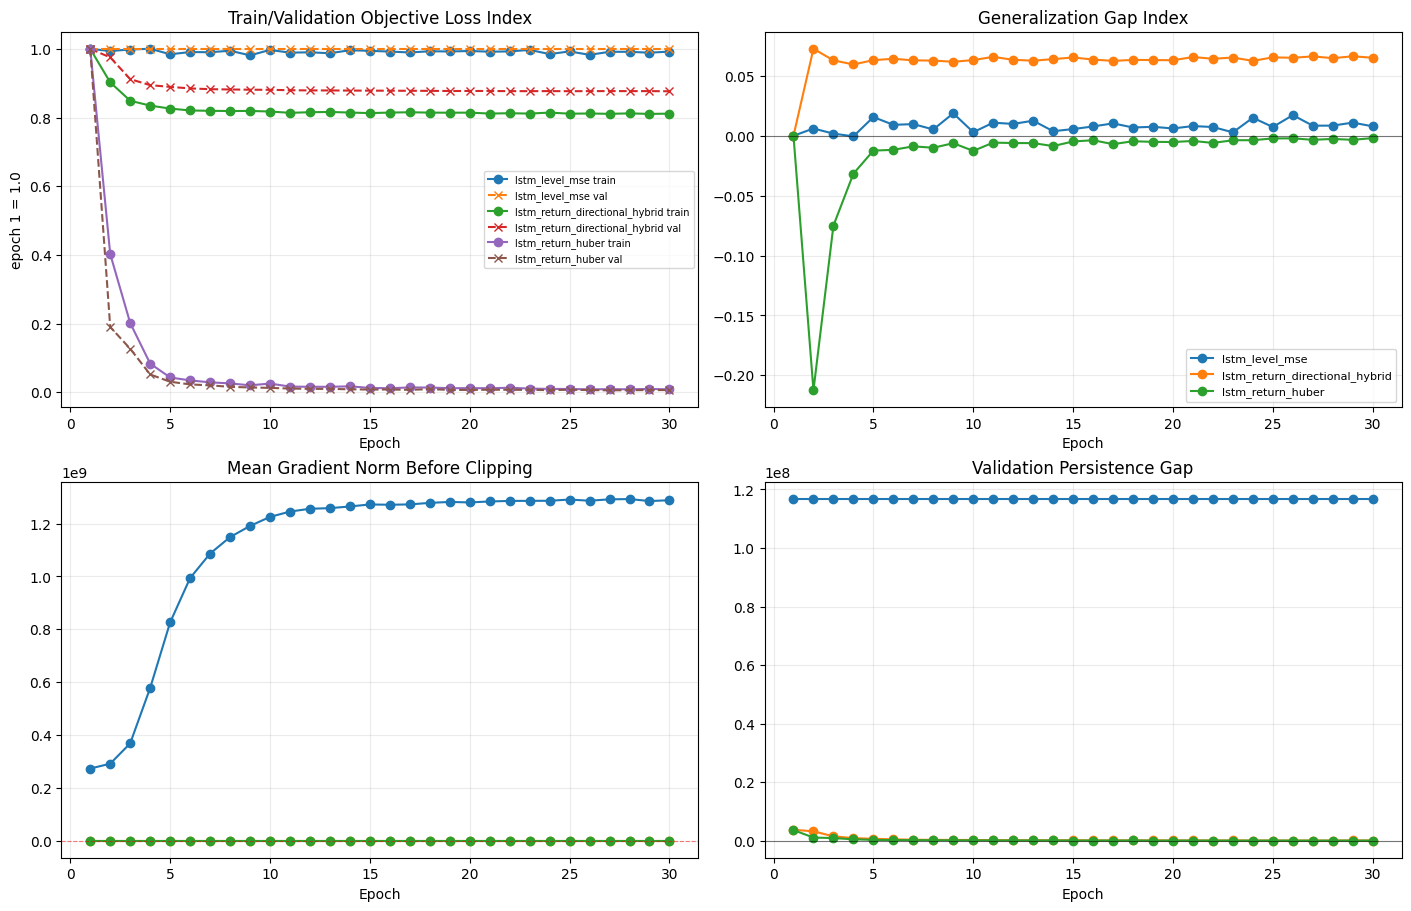

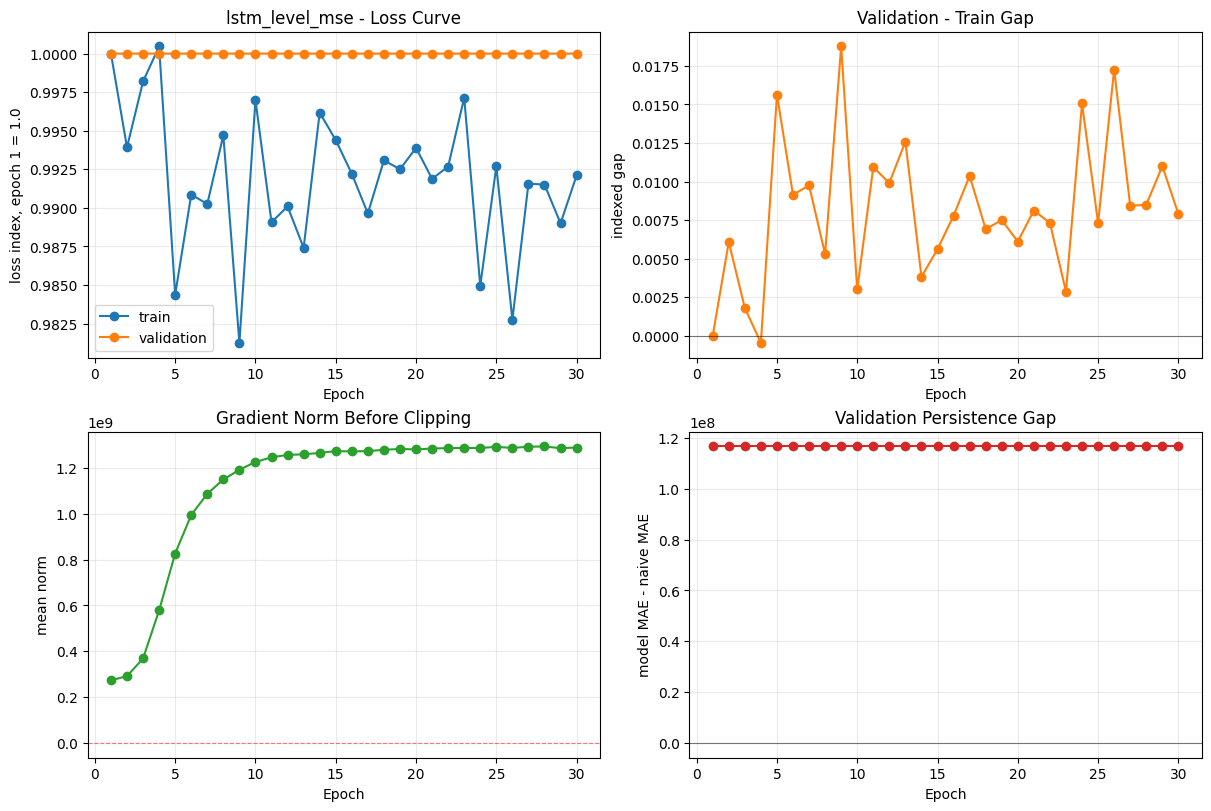

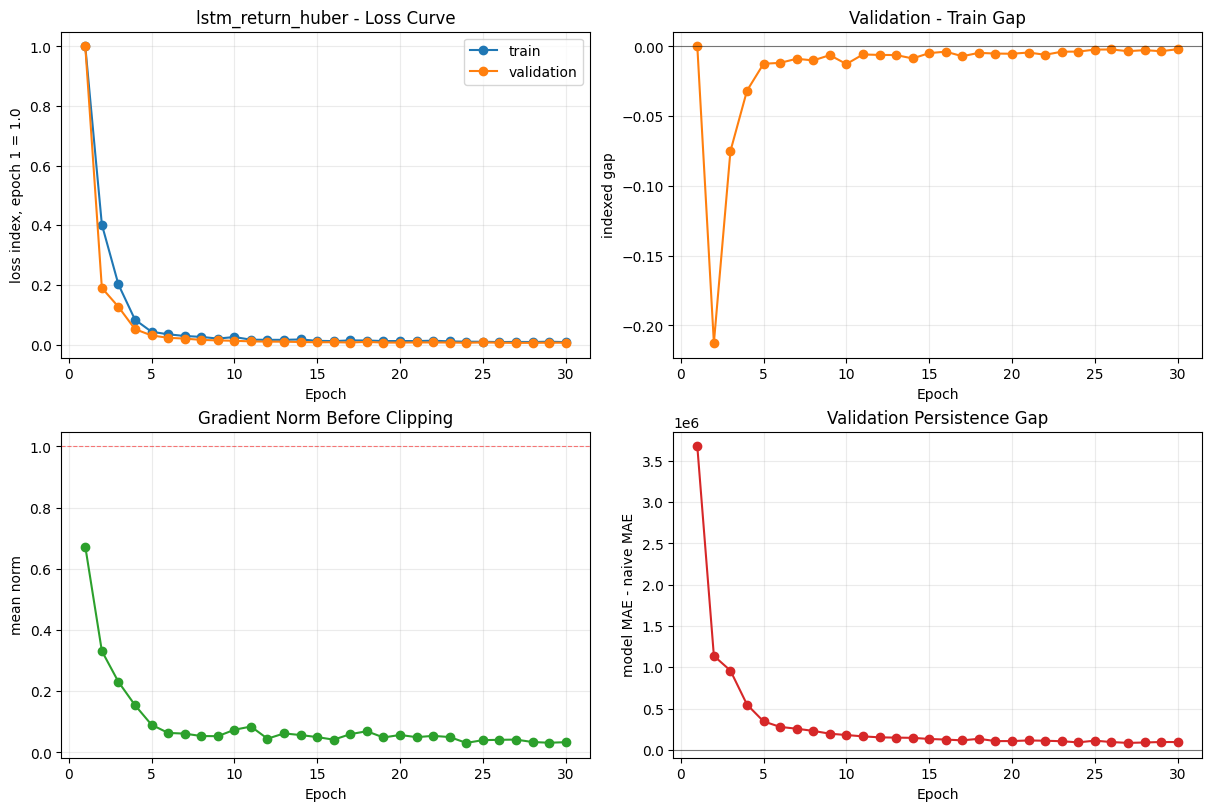

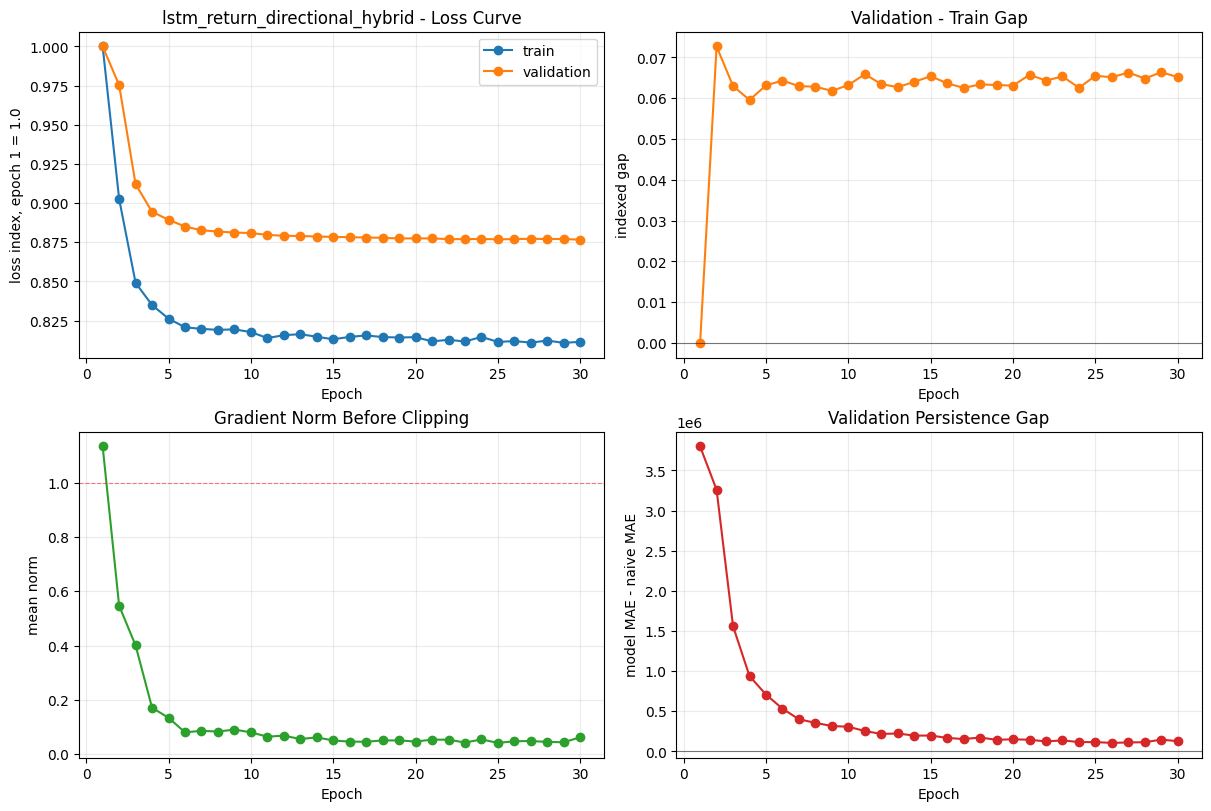

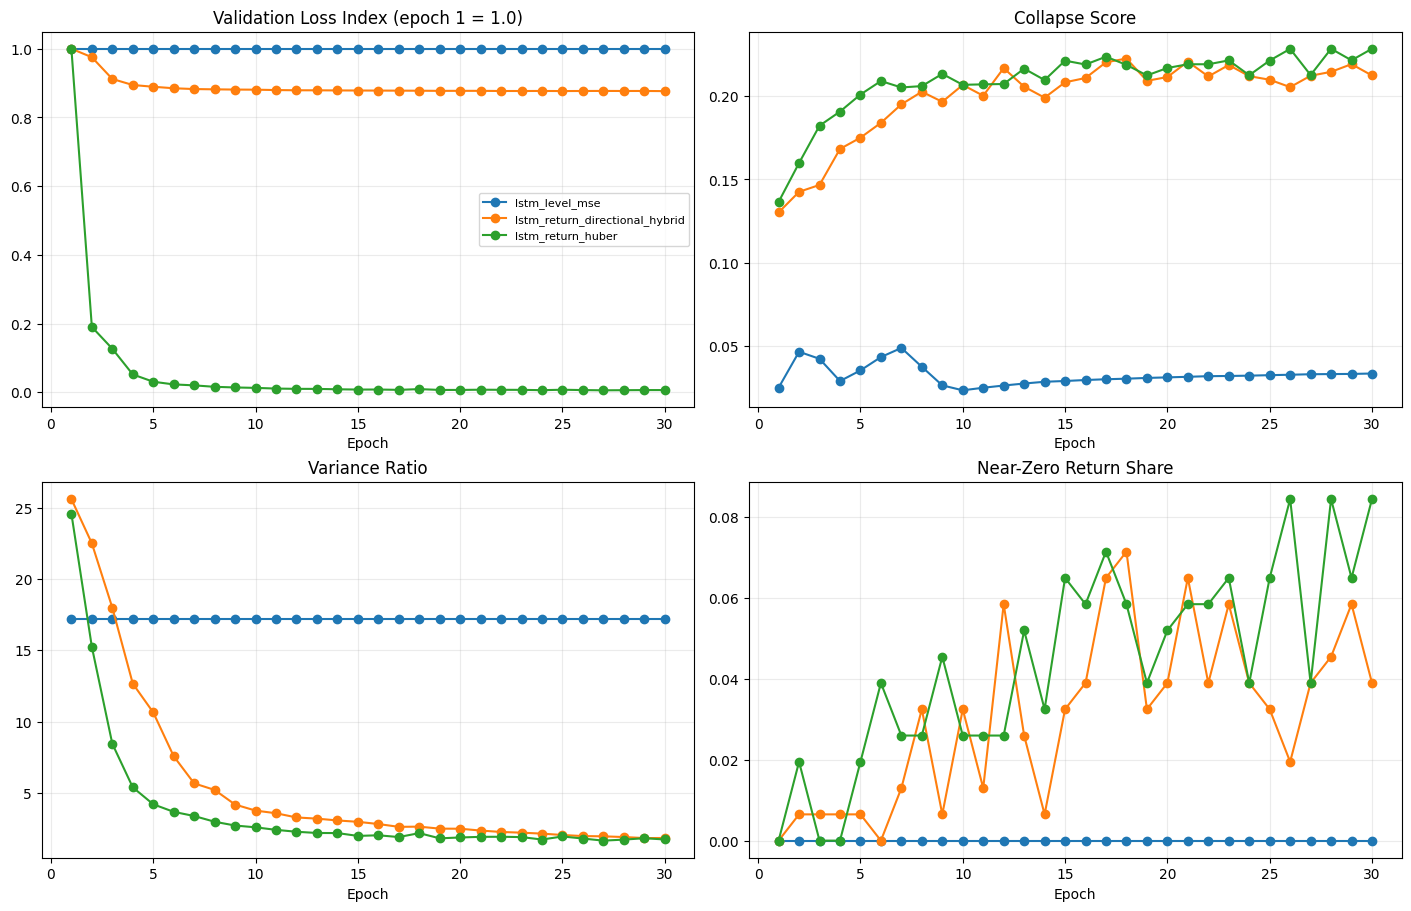

In [9]:
"""Optimization diagnostics for research-time training curve analysis.

This module is designed for `/test/models` notebooks that compare
architecture and objective-function behavior without performing local heavy
research runs by default. Actual long runs should happen on the approved
remote/server environment.
"""

import argparse
import math
import time
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path
from typing import Iterable

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


def ensure_repo_root_on_path() -> Path:
    """Allow notebook/server kernels to import repo-local packages reliably."""
    if "REPO_ROOT" in globals():
        candidate = Path(REPO_ROOT)
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        return candidate

    candidates = [Path.cwd(), *Path.cwd().parents]
    try:
        current_file = Path(__file__).resolve()
        candidates.extend([current_file.parent, *current_file.parents])
    except NameError:
        pass

    for candidate in candidates:
        if (candidate / "database" / "paths.py").exists():
            candidate_str = str(candidate)
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return candidate
    raise ModuleNotFoundError(
        "Could not locate the repository root containing 'database/paths.py'. "
        "Run the notebook from inside the quantitative_trading repository or add the repo root to PYTHONPATH."
    )


REPO_ROOT = ensure_repo_root_on_path()

from database.paths import resolve_db_path


TEXT_FEATURE_COLUMNS = [
    "text_event_count",
    "text_sentiment_mean",
    "text_sentiment_sum",
    "text_sentiment_abs_mean",
    "text_positive_hits",
    "text_negative_hits",
    "text_macro_count",
    "text_risk_count",
    "text_crypto_count",
    "text_regulation_count",
    "text_liquidity_count",
    "text_news_count",
    "text_report_count",
    "text_sns_count",
    "text_shock_z",
    "text_sentiment_momentum_1h",
]

MARKET_FEATURE_COLUMNS = [
    "log_return_1",
    "return_4",
    "return_16",
    "realized_vol_16",
    "hl_range_pct",
    "gk_volatility",
    "rsi_14",
    "roc_12",
    "bb_width_20",
    "sma_spread_5_20",
    "breakout_distance",
    "volume_z_96",
    "value_z_96",
    "amihud_illiq",
    "turnover_proxy",
    "spread_proxy",
]

OPTIMIZATION_PROBE_FEATURE_COLUMNS = [
    "log_return_1",
    "return_4",
    "realized_vol_16",
    "hl_range_pct",
    "volume_z_96",
    "spread_proxy",
]

FEATURE_SETS = {
    "optimization_probe": OPTIMIZATION_PROBE_FEATURE_COLUMNS,
    "market_only": MARKET_FEATURE_COLUMNS,
    "text_aware": MARKET_FEATURE_COLUMNS + TEXT_FEATURE_COLUMNS,
}


@dataclass(frozen=True)
class ExperimentConfig:
    db_path: str = "data/upbit_data.db"
    price_table: str = "btc_15m_advance"
    output_dir: str = "test/results"
    image_dir: str = "test/images"
    save_artifacts: bool = False
    save_csv: bool = False
    ticker: str | None = None
    feature_set: str = "optimization_probe"
    suite: str = "quick_probe"
    seq_len: int = 32
    max_rows: int | None = 35040
    max_windows: int | None = 1024
    window_stride: int = 4
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    epochs: int = 30
    batch_size: int = 64
    learning_rate: float = 0.001
    weight_decay: float = 0.0001
    hidden_dim: int = 32
    n_heads: int = 2
    grad_clip_norm: float = 1.0
    seed: int = 42
    device: str = "auto"
    bootstrap_if_missing: bool = True
    bootstrap_ticker: str = "KRW-BTC"
    bootstrap_days: int = 365


@dataclass(frozen=True)
class CaseSpec:
    name: str
    suite: str
    algorithm: str
    target_mode: str
    objective_mode: str
    description: str


QUICK_PROBE_CASES = [
    CaseSpec(
        name="lstm_level_mse",
        suite="quick_probe",
        algorithm="lstm",
        target_mode="next_close_level",
        objective_mode="mse",
        description="Direct next-close regression as the fastest copy-risk control case.",
    ),
    CaseSpec(
        name="lstm_return_huber",
        suite="quick_probe",
        algorithm="lstm",
        target_mode="next_log_return",
        objective_mode="huber",
        description="Compact robust-return probe for a fast collapse check.",
    ),
    CaseSpec(
        name="lstm_return_directional_hybrid",
        suite="quick_probe",
        algorithm="lstm",
        target_mode="next_log_return",
        objective_mode="directional_hybrid",
        description="Return regression plus direction penalty to test shortcut suppression quickly.",
    ),
]

OBJECTIVE_PROBE_CASES = [
    CaseSpec(
        name="lstm_level_mse",
        suite="objective_probe",
        algorithm="lstm",
        target_mode="next_close_level",
        objective_mode="mse",
        description="Direct next-close regression. Useful as the copy-risk control case.",
    ),
    CaseSpec(
        name="lstm_return_mse",
        suite="objective_probe",
        algorithm="lstm",
        target_mode="next_log_return",
        objective_mode="mse",
        description="One-step log-return regression with plain MSE.",
    ),
    CaseSpec(
        name="lstm_return_huber",
        suite="objective_probe",
        algorithm="lstm",
        target_mode="next_log_return",
        objective_mode="huber",
        description="Robust return regression using SmoothL1/Huber loss.",
    ),
    CaseSpec(
        name="lstm_return_directional_hybrid",
        suite="objective_probe",
        algorithm="lstm",
        target_mode="next_log_return",
        objective_mode="directional_hybrid",
        description="Regression plus sign-consistency penalty to reduce zero-return collapse.",
    ),
]

ARCHITECTURE_PROBE_CASES = [
    CaseSpec(
        name=f"{algorithm}_directional_hybrid",
        suite="architecture_probe",
        algorithm=algorithm,
        target_mode="next_log_return",
        objective_mode="directional_hybrid",
        description="Shared objective to isolate architectural differences in optimization behavior.",
    )
    for algorithm in ("linear", "lstm", "gru")
]

FULL_MATRIX_CASES = [
    CaseSpec(
        name=f"{algorithm}_{objective_mode}",
        suite="full_matrix",
        algorithm=algorithm,
        target_mode="next_log_return" if objective_mode != "level_mse" else "next_close_level",
        objective_mode="mse" if objective_mode == "level_mse" else objective_mode,
        description="Crossed architecture/objective probe.",
    )
    for algorithm in ("linear", "lstm", "gru")
    for objective_mode in ("level_mse", "huber", "directional_hybrid")
]

SUITE_CASES = {
    "quick_probe": QUICK_PROBE_CASES,
    "objective_probe": OBJECTIVE_PROBE_CASES,
    "architecture_probe": ARCHITECTURE_PROBE_CASES,
    "full_matrix": FULL_MATRIX_CASES,
}

PRICE_TABLE_CANDIDATES = [
    "btc_15m_advance",
    "upbit_krw_candle",
    "btc_15m",
]


def compatible_num_heads(hidden_dim: int, requested: int) -> int:
    for candidate in range(min(hidden_dim, requested), 0, -1):
        if hidden_dim % candidate == 0:
            return candidate
    return 1


class SequenceDataset(Dataset):
    def __init__(
        self,
        features: np.ndarray,
        close_now: np.ndarray,
        close_next: np.ndarray,
        return_next: np.ndarray,
        volatility_next: np.ndarray,
        direction_next: np.ndarray,
        seq_len: int,
    ) -> None:
        self.features = torch.tensor(features, dtype=torch.float32)
        self.close_now = torch.tensor(close_now, dtype=torch.float32)
        self.close_next = torch.tensor(close_next, dtype=torch.float32)
        self.return_next = torch.tensor(return_next, dtype=torch.float32)
        self.volatility_next = torch.tensor(volatility_next, dtype=torch.float32)
        self.direction_next = torch.tensor(direction_next, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self) -> int:
        return len(self.features)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        return {
            "x": self.features[index],
            "close_now": self.close_now[index],
            "close_next": self.close_next[index],
            "return_next": self.return_next[index],
            "volatility_next": self.volatility_next[index],
            "direction_next": self.direction_next[index],
        }


class LinearProbe(nn.Module):
    def __init__(self, input_dim: int, seq_len: int, hidden_dim: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim * seq_len, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class RecurrentProbe(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, kind: str) -> None:
        super().__init__()
        rnn_cls = nn.LSTM if kind == "lstm" else nn.GRU
        self.rnn = rnn_cls(input_dim, hidden_dim, batch_first=True, num_layers=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, hidden = self.rnn(x)
        if isinstance(hidden, tuple):
            hidden = hidden[0]
        return hidden[-1]


class TCNProbe(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=2, dilation=1),
            nn.GELU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=4, dilation=2),
            nn.GELU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=8, dilation=4),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.conv(x.transpose(1, 2))
        return y[..., -1]


class TransformerProbe(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, n_heads: int) -> None:
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=compatible_num_heads(hidden_dim, n_heads),
            dim_feedforward=hidden_dim * 2,
            batch_first=True,
            dropout=0.0,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.input_proj(x)
        y = self.encoder(y)
        return self.norm(y[:, -1, :])


class ForecastHead(nn.Module):
    def __init__(self, hidden_dim: int, directional: bool) -> None:
        super().__init__()
        self.value_head = nn.Linear(hidden_dim, 1)
        self.directional = directional
        self.direction_head = nn.Linear(hidden_dim, 1) if directional else None

    def forward(self, z: torch.Tensor) -> dict[str, torch.Tensor]:
        out = {"value": self.value_head(z).squeeze(-1)}
        if self.directional and self.direction_head is not None:
            out["direction_logit"] = self.direction_head(z).squeeze(-1)
        return out


class ForecastModel(nn.Module):
    def __init__(self, config: ExperimentConfig, algorithm: str, input_dim: int) -> None:
        super().__init__()
        hidden_dim = config.hidden_dim
        if algorithm == "linear":
            self.backbone = LinearProbe(input_dim=input_dim, seq_len=config.seq_len, hidden_dim=hidden_dim)
        elif algorithm == "lstm":
            self.backbone = RecurrentProbe(input_dim=input_dim, hidden_dim=hidden_dim, kind="lstm")
        elif algorithm == "gru":
            self.backbone = RecurrentProbe(input_dim=input_dim, hidden_dim=hidden_dim, kind="gru")
        elif algorithm == "tcn":
            self.backbone = TCNProbe(input_dim=input_dim, hidden_dim=hidden_dim)
        elif algorithm == "transformer":
            self.backbone = TransformerProbe(input_dim=input_dim, hidden_dim=hidden_dim, n_heads=config.n_heads)
        else:
            raise ValueError(f"Unsupported algorithm: {algorithm}")
        self.head = ForecastHead(hidden_dim=hidden_dim, directional=True)

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        z = self.backbone(x)
        return self.head(z)


def table_exists(con: duckdb.DuckDBPyConnection, table_name: str) -> bool:
    return bool(
        con.execute(
            """
            SELECT COUNT(*)
            FROM information_schema.tables
            WHERE table_name = ?
            """,
            [table_name],
        ).fetchone()[0]
    )


def list_main_tables(con: duckdb.DuckDBPyConnection) -> list[str]:
    rows = con.execute(
        """
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'main'
        ORDER BY table_name
        """
    ).fetchall()
    return [row[0] for row in rows]


def resolve_price_table(con: duckdb.DuckDBPyConnection, requested: str) -> str:
    if table_exists(con, requested):
        return requested

    available = list_main_tables(con)
    for candidate in PRICE_TABLE_CANDIDATES:
        if candidate in available:
            print(
                f"[table-resolve] Requested price table '{requested}' was not found. "
                f"Using fallback table '{candidate}'."
            )
            return candidate

    raise RuntimeError(
        "Price table not found in DuckDB. "
        f"requested='{requested}', available_tables={available}"
    )


def bootstrap_price_table_if_missing(config: ExperimentConfig) -> str | None:
    if not config.bootstrap_if_missing:
        return None

    try:
        import pyupbit
    except ImportError as exc:
        raise RuntimeError(
            "No reusable price table exists in DuckDB and pyupbit is not available for bootstrap."
        ) from exc

    db_path = Path(config.db_path)
    db_path.parent.mkdir(parents=True, exist_ok=True)

    print(
        "[table-bootstrap] No reusable price table was found. "
        f"Building '{config.price_table}' from {config.bootstrap_ticker} 15-minute candles "
        f"for the last {config.bootstrap_days} days."
    )

    df_list: list[pd.DataFrame] = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=config.bootstrap_days)
    current_to = end_date

    while current_to > start_date:
        df = pyupbit.get_ohlcv(
            config.bootstrap_ticker,
            interval="minute15",
            to=current_to.strftime("%Y-%m-%d %H:%M:%S"),
            count=200,
        )
        if df is None or df.empty:
            break
        df_list.append(df)
        current_to = df.index[0]
        time.sleep(0.12)

    if not df_list:
        raise RuntimeError(
            "Price table bootstrap failed because pyupbit returned no candle data."
        )

    full_df = pd.concat(df_list).sort_index()
    full_df = full_df[~full_df.index.duplicated(keep="first")]
    full_df = full_df.loc[full_df.index >= pd.Timestamp(start_date)].copy()
    full_df.reset_index(inplace=True)
    full_df.rename(columns={"index": "timestamp"}, inplace=True)
    full_df["ticker"] = config.bootstrap_ticker
    if "value" not in full_df.columns:
        full_df["value"] = full_df["close"] * full_df["volume"]

    with duckdb.connect(config.db_path) as con:
        con.register("bootstrap_df", full_df)
        con.execute(f"CREATE OR REPLACE TABLE {config.price_table} AS SELECT * FROM bootstrap_df")

    print(
        f"[table-bootstrap] Created '{config.price_table}' with {len(full_df)} rows "
        f"at {config.db_path}."
    )
    return config.price_table


def rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std().replace(0, np.nan)
    return (series - rolling_mean) / rolling_std


def garman_klass_volatility(df: pd.DataFrame) -> pd.Series:
    log_hl = np.log(df["high"] / df["low"]).replace([np.inf, -np.inf], np.nan)
    log_co = np.log(df["close"] / df["open"]).replace([np.inf, -np.inf], np.nan)
    return np.sqrt(0.5 * log_hl.pow(2) - (2 * np.log(2) - 1) * log_co.pow(2))


def load_price_with_text_features(config: ExperimentConfig) -> pd.DataFrame:
    limit_sql = f"LIMIT {int(config.max_rows)}" if config.max_rows else ""
    with duckdb.connect(config.db_path) as con:
        try:
            price_table = resolve_price_table(con, config.price_table)
        except RuntimeError:
            con.close()
            bootstrapped_table = bootstrap_price_table_if_missing(config)
            with duckdb.connect(config.db_path) as rebuilt_con:
                price_table = resolve_price_table(rebuilt_con, bootstrapped_table or config.price_table)
                table_columns = {row[1] for row in rebuilt_con.execute(f"PRAGMA table_info('{price_table}')").fetchall()}
                ticker_expr = "ticker" if "ticker" in table_columns else "'KRW-BTC' AS ticker"
                value_expr = "value" if "value" in table_columns else "close * volume AS value"

                params: list[object] = []
                where_sql = ""
                if config.ticker:
                    if "ticker" in table_columns:
                        where_sql = "WHERE ticker = ?"
                        params.append(config.ticker)
                    else:
                        where_sql = "WHERE 'KRW-BTC' = ?"
                        params.append(config.ticker)

                price_df = rebuilt_con.execute(
                    f"""
                    SELECT timestamp, open, high, low, close, volume, {value_expr}, {ticker_expr}
                    FROM {price_table}
                    {where_sql}
                    ORDER BY timestamp DESC
                    {limit_sql}
                    """,
                    params,
                ).df()

                text_exists = table_exists(rebuilt_con, "text_features_15m")
                if text_exists:
                    text_df = rebuilt_con.execute(
                        f"""
                        SELECT timestamp, {", ".join(TEXT_FEATURE_COLUMNS)}
                        FROM text_features_15m
                        ORDER BY timestamp
                        """
                    ).df()
                else:
                    text_df = pd.DataFrame(columns=["timestamp", *TEXT_FEATURE_COLUMNS])

            if price_df.empty:
                raise RuntimeError("No rows loaded after table bootstrap. Check ticker or bootstrap window.")

            price_df = price_df.sort_values("timestamp").reset_index(drop=True)
            price_df["timestamp"] = pd.to_datetime(price_df["timestamp"]).dt.floor("15min")
            text_df["timestamp"] = pd.to_datetime(text_df["timestamp"]).dt.floor("15min")
            merged = price_df.merge(text_df, on="timestamp", how="left")
            for column in TEXT_FEATURE_COLUMNS:
                if column not in merged.columns:
                    merged[column] = 0.0
            merged[TEXT_FEATURE_COLUMNS] = merged[TEXT_FEATURE_COLUMNS].fillna(0.0)
            return merged.sort_values(["ticker", "timestamp"]).reset_index(drop=True)

        table_columns = {row[1] for row in con.execute(f"PRAGMA table_info('{price_table}')").fetchall()}
        ticker_expr = "ticker" if "ticker" in table_columns else "'KRW-BTC' AS ticker"
        value_expr = "value" if "value" in table_columns else "close * volume AS value"

        params: list[object] = []
        where_sql = ""
        if config.ticker:
            if "ticker" in table_columns:
                where_sql = "WHERE ticker = ?"
                params.append(config.ticker)
            else:
                where_sql = "WHERE 'KRW-BTC' = ?"
                params.append(config.ticker)

        price_df = con.execute(
            f"""
            SELECT timestamp, open, high, low, close, volume, {value_expr}, {ticker_expr}
            FROM {price_table}
            {where_sql}
            ORDER BY timestamp DESC
            {limit_sql}
            """,
            params,
        ).df()

        text_exists = table_exists(con, "text_features_15m")
        if text_exists:
            text_df = con.execute(
                f"""
                SELECT timestamp, {", ".join(TEXT_FEATURE_COLUMNS)}
                FROM text_features_15m
                ORDER BY timestamp
                """
            ).df()
        else:
            text_df = pd.DataFrame(columns=["timestamp", *TEXT_FEATURE_COLUMNS])

    if price_df.empty:
        raise RuntimeError("No rows loaded. Check table, ticker, or max_rows.")

    price_df = price_df.sort_values("timestamp").reset_index(drop=True)
    price_df["timestamp"] = pd.to_datetime(price_df["timestamp"]).dt.floor("15min")
    text_df["timestamp"] = pd.to_datetime(text_df["timestamp"]).dt.floor("15min")
    merged = price_df.merge(text_df, on="timestamp", how="left")
    for column in TEXT_FEATURE_COLUMNS:
        if column not in merged.columns:
            merged[column] = 0.0
    merged[TEXT_FEATURE_COLUMNS] = merged[TEXT_FEATURE_COLUMNS].fillna(0.0)
    return merged.sort_values(["ticker", "timestamp"]).reset_index(drop=True)


def add_market_features(df: pd.DataFrame) -> pd.DataFrame:
    out_frames: list[pd.DataFrame] = []
    for ticker, ticker_df in df.groupby("ticker", sort=False):
        tdf = ticker_df.sort_values("timestamp").copy()
        close = tdf["close"].replace(0, np.nan)
        value = tdf["value"].replace(0, np.nan)
        volume = tdf["volume"].replace(0, np.nan)

        tdf["log_return_1"] = np.log(close).diff()
        tdf["return_4"] = close.pct_change(4)
        tdf["return_16"] = close.pct_change(16)
        tdf["realized_vol_16"] = tdf["log_return_1"].rolling(16).std()
        tdf["hl_range_pct"] = (tdf["high"] - tdf["low"]) / close
        tdf["gk_volatility"] = garman_klass_volatility(tdf)

        delta = close.diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / loss.replace(0, np.nan)
        tdf["rsi_14"] = 100.0 - (100.0 / (1.0 + rs))
        tdf["roc_12"] = close.pct_change(12)

        sma_5 = close.rolling(5).mean()
        sma_20 = close.rolling(20).mean()
        std_20 = close.rolling(20).std()
        tdf["bb_width_20"] = ((sma_20 + 2 * std_20) - (sma_20 - 2 * std_20)) / close
        tdf["sma_spread_5_20"] = (sma_5 - sma_20) / close
        rolling_high_96 = tdf["high"].rolling(96).max()
        tdf["breakout_distance"] = (close - rolling_high_96) / close

        tdf["volume_z_96"] = rolling_zscore(volume, 96)
        tdf["value_z_96"] = rolling_zscore(value, 96)
        tdf["amihud_illiq"] = close.pct_change().abs() / value.replace(0, np.nan)
        tdf["turnover_proxy"] = value / value.rolling(96).mean()
        tdf["spread_proxy"] = (tdf["high"] - tdf["low"]) / close
        out_frames.append(tdf)
    return pd.concat(out_frames, axis=0).sort_values(["ticker", "timestamp"]).reset_index(drop=True)


def prepare_feature_frame(config: ExperimentConfig) -> pd.DataFrame:
    df = load_price_with_text_features(config)
    df = add_market_features(df)
    feature_columns = FEATURE_SETS[config.feature_set]
    required_columns = ["timestamp", "ticker", "close", *feature_columns]
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise RuntimeError(f"Missing required columns: {missing}")

    df["next_close"] = df.groupby("ticker")["close"].shift(-1)
    df["next_log_return"] = np.log(df["next_close"] / df["close"])
    df["next_direction"] = (df["next_log_return"] > 0).astype(float)
    df["next_volatility"] = df.groupby("ticker")["realized_vol_16"].shift(-1)

    clean_columns = ["close", "next_close", "next_log_return", "next_direction", "next_volatility", *feature_columns]
    df = df.dropna(subset=clean_columns).reset_index(drop=True)
    return df


def standardize_train_applied(train: np.ndarray, other: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = train.mean(axis=0, keepdims=True)
    std = train.std(axis=0, keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)
    return (train - mean) / std, (other - mean) / std


def build_splits(config: ExperimentConfig, df: pd.DataFrame) -> tuple[dict[str, SequenceDataset], list[str]]:
    feature_columns = FEATURE_SETS[config.feature_set]
    features = df[feature_columns].to_numpy(dtype=np.float32)
    close = df["close"].to_numpy(dtype=np.float32)
    next_close = df["next_close"].to_numpy(dtype=np.float32)
    next_return = df["next_log_return"].to_numpy(dtype=np.float32)
    next_vol = df["next_volatility"].to_numpy(dtype=np.float32)
    next_dir = df["next_direction"].to_numpy(dtype=np.float32)

    sequences: list[np.ndarray] = []
    close_now_list: list[float] = []
    close_next_list: list[float] = []
    return_next_list: list[float] = []
    vol_next_list: list[float] = []
    dir_next_list: list[float] = []

    for end_idx in range(config.seq_len - 1, len(df), max(1, config.window_stride)):
        start_idx = end_idx - config.seq_len + 1
        sequences.append(features[start_idx : end_idx + 1])
        close_now_list.append(close[end_idx])
        close_next_list.append(next_close[end_idx])
        return_next_list.append(next_return[end_idx])
        vol_next_list.append(next_vol[end_idx])
        dir_next_list.append(next_dir[end_idx])

    X = np.stack(sequences)
    close_now_arr = np.asarray(close_now_list, dtype=np.float32)
    close_next_arr = np.asarray(close_next_list, dtype=np.float32)
    return_next_arr = np.asarray(return_next_list, dtype=np.float32)
    vol_next_arr = np.asarray(vol_next_list, dtype=np.float32)
    dir_next_arr = np.asarray(dir_next_list, dtype=np.float32)

    if config.max_windows and len(X) > config.max_windows:
        sampled_idx = np.linspace(0, len(X) - 1, num=config.max_windows, dtype=int)
        X = X[sampled_idx]
        close_now_arr = close_now_arr[sampled_idx]
        close_next_arr = close_next_arr[sampled_idx]
        return_next_arr = return_next_arr[sampled_idx]
        vol_next_arr = vol_next_arr[sampled_idx]
        dir_next_arr = dir_next_arr[sampled_idx]

    total = len(X)
    if total < 64:
        raise RuntimeError(
            f"Not enough sequence windows for diagnostics: {total}. Increase max_rows or reduce seq_len."
        )
    train_end = max(config.seq_len + 10, int(total * config.train_ratio))
    val_end = max(train_end + 10, int(total * (config.train_ratio + config.val_ratio)))
    val_end = min(val_end, total - 1)
    if train_end >= val_end or val_end >= total:
        raise RuntimeError(
            f"Invalid split sizes derived from {total} windows. Adjust train_ratio/val_ratio/max_rows."
        )

    X_train = X[:train_end]
    X_val = X[train_end:val_end]
    X_test = X[val_end:]
    X_train_scaled, X_val_scaled = standardize_train_applied(X_train, X_val)
    _, X_test_scaled = standardize_train_applied(X_train, X_test)

    splits = {
        "train": SequenceDataset(
            features=X_train_scaled,
            close_now=close_now_arr[:train_end],
            close_next=close_next_arr[:train_end],
            return_next=return_next_arr[:train_end],
            volatility_next=vol_next_arr[:train_end],
            direction_next=dir_next_arr[:train_end],
            seq_len=config.seq_len,
        ),
        "val": SequenceDataset(
            features=X_val_scaled,
            close_now=close_now_arr[train_end:val_end],
            close_next=close_next_arr[train_end:val_end],
            return_next=return_next_arr[train_end:val_end],
            volatility_next=vol_next_arr[train_end:val_end],
            direction_next=dir_next_arr[train_end:val_end],
            seq_len=config.seq_len,
        ),
        "test": SequenceDataset(
            features=X_test_scaled,
            close_now=close_now_arr[val_end:],
            close_next=close_next_arr[val_end:],
            return_next=return_next_arr[val_end:],
            volatility_next=vol_next_arr[val_end:],
            direction_next=dir_next_arr[val_end:],
            seq_len=config.seq_len,
        ),
    }
    return splits, feature_columns


def format_number(value: float | int, digits: int = 4) -> str:
    if isinstance(value, (int, np.integer)):
        return f"{int(value):,}"
    if value is None or pd.isna(value):
        return "NA"
    return f"{float(value):,.{digits}f}"


def build_dataset_profile(
    config: ExperimentConfig,
    df: pd.DataFrame,
    datasets: dict[str, SequenceDataset],
    feature_columns: list[str],
) -> dict[str, object]:
    close = df["close"].astype(float)
    next_return = df["next_log_return"].astype(float)
    timestamps = pd.to_datetime(df["timestamp"])
    return {
        "db_path": config.db_path,
        "price_table": config.price_table,
        "ticker_filter": config.ticker or "ALL",
        "row_count": len(df),
        "ticker_count": int(df["ticker"].nunique()) if "ticker" in df.columns else 1,
        "start_time": timestamps.min(),
        "end_time": timestamps.max(),
        "feature_columns": feature_columns,
        "train_windows": len(datasets["train"]),
        "val_windows": len(datasets["val"]),
        "test_windows": len(datasets["test"]),
        "close_mean": close.mean(),
        "close_std": close.std(),
        "close_min": close.min(),
        "close_median": close.median(),
        "close_max": close.max(),
        "return_mean": next_return.mean(),
        "return_std": next_return.std(),
        "return_abs_mean": next_return.abs().mean(),
        "return_positive_share": float((next_return > 0).mean()),
    }


def dataset_profile_lines(profile: dict[str, object]) -> list[str]:
    feature_columns = profile["feature_columns"]
    assert isinstance(feature_columns, list)
    return [
        "## 3. 데이터 및 처리 조건",
        "",
        "아래 조건은 이번 최적화 진단이 어떤 데이터에서 수행되었는지 설명한다. 손실함수만 보는 것이 아니라, 데이터 기간과 분할 구조를 함께 봐야 학습 곡선의 의미를 해석할 수 있다.",
        "",
        f"- DuckDB 경로: `{profile['db_path']}`",
        f"- 가격 테이블: `{profile['price_table']}`",
        f"- 티커 필터: `{profile['ticker_filter']}`",
        f"- 사용 행 수: `{format_number(profile['row_count'], 0)}`",
        f"- 종목 수: `{format_number(profile['ticker_count'], 0)}`",
        f"- 기간: `{profile['start_time']}` ~ `{profile['end_time']}`",
        f"- 입력 변수 수: `{len(feature_columns)}`",
        f"- 입력 변수: `{', '.join(feature_columns)}`",
        f"- 시퀀스 분할: train `{format_number(profile['train_windows'], 0)}`, validation `{format_number(profile['val_windows'], 0)}`, test `{format_number(profile['test_windows'], 0)}`",
        "",
        "### 3.1 기초 통계량",
        "",
        "| 항목 | 값 | 해석 |",
        "| --- | ---: | --- |",
        f"| Close 평균 | {format_number(profile['close_mean'])} | 가격 레벨의 중심 크기 |",
        f"| Close 표준편차 | {format_number(profile['close_std'])} | 가격 레벨의 변동 폭 |",
        f"| Close 최소값 | {format_number(profile['close_min'])} | 분석 구간 내 최저 가격 |",
        f"| Close 중앙값 | {format_number(profile['close_median'])} | 극단값 영향을 줄인 중심 가격 |",
        f"| Close 최대값 | {format_number(profile['close_max'])} | 분석 구간 내 최고 가격 |",
        f"| 다음 로그수익률 평균 | {format_number(profile['return_mean'], 8)} | 다음 15분 변동의 평균 방향 |",
        f"| 다음 로그수익률 표준편차 | {format_number(profile['return_std'], 8)} | 다음 15분 변동성 크기 |",
        f"| 절대 로그수익률 평균 | {format_number(profile['return_abs_mean'], 8)} | 평균적인 1-step 변동 강도 |",
        f"| 상승 비율 | {format_number(profile['return_positive_share'])} | 다음 봉이 상승한 비율, 0.5 근처면 방향 예측 난도 높음 |",
        "",
    ]


def optimization_methodology_lines() -> list[str]:
    return [
        "## 4. 방법론 및 진단 지표 정의",
        "",
        "이 절은 결과를 보기 전에 각 지표가 무엇을 의미하는지 정의한다. 본 실험의 목적은 최종 수익률을 주장하는 것이 아니라, 손실함수와 모델 구조가 비정상 금융 시계열에서 어떤 방식으로 최적화되는지 진단하는 것이다.",
        "",
        "### 4.1 Train/Validation Loss Curve",
        "",
        "- 개념: epoch가 진행될 때 학습 데이터 손실(train loss)과 검증 데이터 손실(validation loss)이 어떻게 움직이는지 보는 기본 최적화 곡선이다.",
        "- 사용 이유: 모델이 단순히 train 데이터만 외우는지, 아니면 보지 않은 validation 구간에서도 손실이 줄어드는지 확인하기 위해 사용한다.",
        "- 정의: `train_loss = L(y_train, yhat_train)`, `validation_loss = L(y_val, yhat_val)`이며, 본 실험에서는 서로 다른 손실함수 스케일을 비교하기 위해 첫 epoch 값을 1.0으로 둔 loss index도 함께 본다.",
        "- 해석 예시: train과 validation이 함께 하락하면 학습이 진행되는 것이다. train만 하락하고 validation이 정체되면 과적합 또는 쉬운 해로의 붕괴 가능성이 있다.",
        "- 장점: 가장 직관적으로 최적화 과정의 수렴, 정체, 발산을 확인할 수 있다.",
        "- 한계: 금융 시계열에서는 validation loss가 낮아도 방향성 또는 매매 가능성이 보장되지 않는다. 따라서 persistence gap, sign agreement 같은 보조 지표가 필요하다.",
        "",
        "### 4.2 Generalization Gap",
        "",
        "- 개념: validation loss와 train loss 사이의 차이다.",
        "- 사용 이유: 학습 데이터에서는 좋아지지만 미래 구간에서는 좋아지지 않는 일반화 실패를 확인하기 위해 사용한다.",
        "- 정의: `gap = validation_loss_index - train_loss_index`.",
        "- 해석 예시: gap이 양수로 커지면 train 데이터에는 적응하지만 validation 구간에는 통하지 않는다는 뜻이다.",
        "- 장점: 과적합 여부를 빠르게 볼 수 있다.",
        "- 한계: train/validation 구간 자체가 regime shift를 포함하면 gap은 과적합뿐 아니라 시장 국면 변화의 신호일 수도 있다.",
        "",
        "### 4.3 Gradient Norm Before Clipping",
        "",
        "- 개념: 역전파 후 gradient clipping을 적용하기 직전의 gradient 크기다.",
        "- 사용 이유: 손실함수 스케일이 너무 크거나 모델이 불안정해서 학습이 튀는지 확인하기 위해 사용한다.",
        "- 정의: `||grad|| = sqrt(sum_i grad_i^2)`.",
        "- 해석 예시: gradient norm이 계속 clipping 기준에 붙으면 손실 스케일 또는 target 스케일이 너무 공격적일 수 있다. 반대로 너무 작으면 학습 신호가 약하거나 평평한 해에 갇혔을 수 있다.",
        "- 장점: loss curve만으로 보이지 않는 최적화 안정성을 확인할 수 있다.",
        "- 한계: gradient norm이 안정적이라고 해서 예측력이 좋다는 뜻은 아니다. 안정적으로 잘못된 해에 수렴할 수도 있다.",
        "",
        "### 4.4 Persistence Gap",
        "",
        "- 개념: 모델의 절대오차가 단순 직전가 복사 기준보다 얼마나 나은지 보는 baseline 비교 지표다.",
        "- 사용 이유: 금융 가격 레벨은 자기상관이 매우 강해서, 복잡한 모델이 실제로는 직전 가격을 베끼는 것보다 못한 경우가 많다.",
        "- 정의: `persistence_gap = MAE(model_prediction, y_next) - MAE(current_price, y_next)`.",
        "- 해석 예시: 값이 0보다 작으면 모델이 naive persistence보다 낫다. 0보다 크면 복잡한 모델을 썼지만 직전가 복사보다 못하다는 뜻이다.",
        "- 장점: 가격 레벨 예측에서 발생하는 기만적 RMSE 착시를 방지한다.",
        "- 한계: persistence baseline은 가격 레벨 기준이다. 방향성 전략이나 변동성 예측에서는 별도의 경제적 baseline도 함께 봐야 한다.",
        "",
        "### 4.5 Collapse Score",
        "",
        "- 개념: 모델이 예측 변동성을 잃거나, 0 수익률만 내거나, 직전 가격과 과도하게 붙는 쉬운 해로 도망가는 위험을 합친 보조 점수다.",
        "- 사용 이유: 손실함수 최적화가 허용하는 가장 쉬운 해가 실제 예측이 아니라 평균/무변화/복사일 수 있기 때문이다.",
        "- 정의: 본 코드에서는 낮은 prediction variance, near-zero return share, copy alignment를 가중 결합한다.",
        "- 해석 예시: 낮은 collapse score는 붕괴 위험이 작다는 뜻일 수 있지만, persistence gap이 양수라면 여전히 예측 모델로 채택하면 안 된다.",
        "- 장점: 모델이 명백히 평평한 예측 또는 복사 예측으로 무너지는지 빠르게 확인할 수 있다.",
        "- 한계: 단일 성능 지표가 아니다. collapse score만 낮다고 좋은 모델이 아니다.",
        "",
        "### 4.6 Near-Zero Return Share",
        "",
        "- 개념: 모델이 예측한 다음 수익률이 거의 0에 가까운 비율이다.",
        "- 사용 이유: 수익률 예측 모델이 '다음에도 거의 안 움직인다'는 평균 해로 붕괴하는지 확인하기 위해 사용한다.",
        "- 정의: `mean(abs(predicted_return) < 1e-4)`.",
        "- 해석 예시: 이 값이 높으면 모델이 가격 변동을 예측하기보다 무변화 예측으로 손실을 낮추고 있을 가능성이 있다.",
        "- 장점: 수익률 target에서 평균 수렴/무변화 예측을 탐지하기 쉽다.",
        "- 한계: 실제 시장이 저변동 구간이면 near-zero 비율이 높게 나올 수 있으므로, realized volatility와 함께 해석해야 한다.",
        "",
        "### 4.7 Sign Agreement",
        "",
        "- 개념: 예측한 가격 변화 방향과 실제 가격 변화 방향의 부호가 일치한 비율이다.",
        "- 사용 이유: 가격 오차가 작아도 상승/하락 방향을 못 맞히면 트레이딩 관점에서 유효성이 낮기 때문이다.",
        "- 정의: `mean(sign(predicted_delta) == sign(actual_delta))`.",
        "- 해석 예시: 0.5 근처면 동전 던지기 수준이다. 유의미한 매매 신호로 보려면 수수료와 슬리피지를 넘는 방향성 우위가 필요하다.",
        "- 장점: 가격 레벨 RMSE의 착시를 보완한다.",
        "- 한계: 방향만 맞고 크기를 틀리면 실제 손익은 나쁠 수 있다.",
        "",
        "### 4.8 알고리즘 가족 설명",
        "",
        "- `Linear`: 입력 윈도우를 한 번에 펴서 가장 단순한 선형 조합으로 예측한다. 장점은 빠르고 해석이 쉬우며, 단점은 시계열 순서 정보를 거의 직접 쓰지 못한다는 점이다.",
        "- `LSTM`: 과거 상태를 게이트로 누적하는 순환 구조다. 장점은 시계열의 순서를 기억할 수 있다는 점이고, 단점은 데이터가 적거나 objective가 거칠면 쉽게 평평한 해로 수렴할 수 있다는 점이다.",
        "- `GRU`: LSTM보다 게이트가 단순한 순환 구조다. 장점은 더 가볍고 빠르게 학습된다는 점이며, 단점은 경우에 따라 복잡한 장기 의존성을 덜 잡을 수 있다는 점이다.",
        "- 이번 실험에서 `Linear`/`LSTM`/`GRU`를 함께 두는 이유는, 복잡도가 높을수록 항상 좋은 것이 아니라는 점을 확인하기 위해서다. 같은 objective에서도 아키텍처가 다르면 붕괴 방식이 달라질 수 있다.",
        "",
    ]


def resolve_device(config: ExperimentConfig) -> torch.device:
    if config.device != "auto":
        return torch.device(config.device)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def compute_case_loss(
    outputs: dict[str, torch.Tensor],
    batch: dict[str, torch.Tensor],
    case: CaseSpec,
) -> torch.Tensor:
    pred_value = outputs["value"]
    direction_logit = outputs["direction_logit"]
    if case.target_mode == "next_close_level":
        target = batch["close_next"]
    else:
        target = batch["return_next"]

    if case.objective_mode == "mse":
        return F.mse_loss(pred_value, target)
    if case.objective_mode == "huber":
        return F.smooth_l1_loss(pred_value, target, beta=0.02)
    if case.objective_mode == "vol_weighted_mse":
        weights = 1.0 + torch.nan_to_num(batch["volatility_next"], nan=0.0).abs() * 10.0
        return torch.mean(weights * torch.square(pred_value - target))
    if case.objective_mode == "directional_hybrid":
        reg = F.smooth_l1_loss(pred_value, target, beta=0.02)
        cls = F.binary_cross_entropy_with_logits(direction_logit, batch["direction_next"])
        return reg + 0.25 * cls
    if case.objective_mode == "tail_focus":
        weights = 1.0 + torch.abs(batch["return_next"]) * 50.0
        reg = torch.mean(weights * torch.square(pred_value - target))
        cls = F.binary_cross_entropy_with_logits(direction_logit, batch["direction_next"])
        return reg + 0.20 * cls
    raise ValueError(f"Unsupported objective mode: {case.objective_mode}")


def infer_close_prediction(case: CaseSpec, batch: dict[str, torch.Tensor], pred_value: torch.Tensor) -> torch.Tensor:
    if case.target_mode == "next_close_level":
        return pred_value
    return batch["close_now"] * torch.exp(pred_value)


def infer_delta_prediction(case: CaseSpec, batch: dict[str, torch.Tensor], pred_value: torch.Tensor) -> torch.Tensor:
    pred_close = infer_close_prediction(case, batch, pred_value)
    return pred_close - batch["close_now"]


def evaluate_epoch(
    model: ForecastModel,
    loader: DataLoader,
    case: CaseSpec,
    device: torch.device,
) -> dict[str, float]:
    model.eval()
    losses: list[float] = []
    pred_close_all: list[np.ndarray] = []
    true_close_all: list[np.ndarray] = []
    current_close_all: list[np.ndarray] = []
    pred_delta_all: list[np.ndarray] = []
    true_delta_all: list[np.ndarray] = []
    pred_return_all: list[np.ndarray] = []

    with torch.no_grad():
        for batch in loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(batch["x"])
            loss = compute_case_loss(outputs, batch, case)
            losses.append(float(loss.item()))

            pred_close = infer_close_prediction(case, batch, outputs["value"])
            true_close = batch["close_next"]
            pred_delta = pred_close - batch["close_now"]
            true_delta = true_close - batch["close_now"]
            pred_return = torch.log(torch.clamp(pred_close / batch["close_now"], min=1e-8))

            pred_close_all.append(pred_close.detach().cpu().numpy())
            true_close_all.append(true_close.detach().cpu().numpy())
            current_close_all.append(batch["close_now"].detach().cpu().numpy())
            pred_delta_all.append(pred_delta.detach().cpu().numpy())
            true_delta_all.append(true_delta.detach().cpu().numpy())
            pred_return_all.append(pred_return.detach().cpu().numpy())

    pred_close_np = np.concatenate(pred_close_all)
    true_close_np = np.concatenate(true_close_all)
    current_close_np = np.concatenate(current_close_all)
    pred_delta_np = np.concatenate(pred_delta_all)
    true_delta_np = np.concatenate(true_delta_all)
    pred_return_np = np.concatenate(pred_return_all)

    persistence_mae = float(np.mean(np.abs(current_close_np - true_close_np)))
    model_mae = float(np.mean(np.abs(pred_close_np - true_close_np)))
    pred_std = float(np.std(pred_delta_np))
    true_std = float(np.std(true_delta_np))
    variance_ratio = pred_std / true_std if true_std > 1e-8 else math.nan
    zero_share = float(np.mean(np.abs(pred_return_np) < 1e-4))
    sign_agreement = float(np.mean(np.sign(pred_delta_np) == np.sign(true_delta_np)))
    copy_alignment = float(np.corrcoef(pred_close_np, current_close_np)[0, 1]) if len(pred_close_np) > 3 else math.nan
    collapse_score = float(
        0.45 * max(0.0, 1.0 - min(variance_ratio if not math.isnan(variance_ratio) else 0.0, 1.0))
        + 0.35 * zero_share
        + 0.20 * max(0.0, copy_alignment if not math.isnan(copy_alignment) else 0.0)
    )

    return {
        "loss": float(np.mean(losses)) if losses else math.nan,
        "model_mae": model_mae,
        "persistence_mae": persistence_mae,
        "persistence_gap": model_mae - persistence_mae,
        "variance_ratio": variance_ratio,
        "zero_share": zero_share,
        "sign_agreement": sign_agreement,
        "copy_alignment": copy_alignment,
        "collapse_score": collapse_score,
    }


def train_case(
    config: ExperimentConfig,
    case: CaseSpec,
    datasets: dict[str, SequenceDataset],
    input_dim: int,
) -> tuple[pd.DataFrame, dict[str, float]]:
    device = resolve_device(config)
    train_loader = DataLoader(datasets["train"], batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(datasets["val"], batch_size=config.batch_size, shuffle=False)
    test_loader = DataLoader(datasets["test"], batch_size=config.batch_size, shuffle=False)

    model = ForecastModel(config=config, algorithm=case.algorithm, input_dim=input_dim).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )

    history_rows: list[dict[str, float | int | str]] = []
    for epoch in range(1, config.epochs + 1):
        model.train()
        train_losses: list[float] = []
        grad_norms: list[float] = []
        for batch in train_loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            outputs = model(batch["x"])
            loss = compute_case_loss(outputs, batch, case)
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip_norm)
            optimizer.step()
            train_losses.append(float(loss.item()))
            grad_norms.append(float(grad_norm.item() if hasattr(grad_norm, "item") else grad_norm))

        train_diag = evaluate_epoch(model, train_loader, case, device)
        val_diag = evaluate_epoch(model, val_loader, case, device)
        history_rows.append(
            {
                "case_name": case.name,
                "algorithm": case.algorithm,
                "objective_mode": case.objective_mode,
                "target_mode": case.target_mode,
                "epoch": epoch,
                "train_step_loss": float(np.mean(train_losses)) if train_losses else math.nan,
                "train_grad_norm": float(np.mean(grad_norms)) if grad_norms else math.nan,
                "train_diag_loss": train_diag["loss"],
                "val_loss": val_diag["loss"],
                "loss_gap": val_diag["loss"] - train_diag["loss"],
                "val_persistence_gap": val_diag["persistence_gap"],
                "val_variance_ratio": val_diag["variance_ratio"],
                "val_zero_share": val_diag["zero_share"],
                "val_sign_agreement": val_diag["sign_agreement"],
                "val_copy_alignment": val_diag["copy_alignment"],
                "val_collapse_score": val_diag["collapse_score"],
            }
        )

    test_diag = evaluate_epoch(model, test_loader, case, device)
    summary = {
        "case_name": case.name,
        "algorithm": case.algorithm,
        "objective_mode": case.objective_mode,
        "target_mode": case.target_mode,
        "description": case.description,
        **test_diag,
    }
    return pd.DataFrame(history_rows), summary


def add_loss_indices(history_df: pd.DataFrame) -> pd.DataFrame:
    plot_df = history_df.copy()
    train_scale = plot_df.groupby("case_name")["train_diag_loss"].transform(lambda series: max(float(series.iloc[0]), 1e-12))
    val_scale = plot_df.groupby("case_name")["val_loss"].transform(lambda series: max(float(series.iloc[0]), 1e-12))
    plot_df["train_loss_index"] = plot_df["train_diag_loss"] / train_scale
    plot_df["val_loss_index"] = plot_df["val_loss"] / val_scale
    plot_df["loss_gap_index"] = plot_df["val_loss_index"] - plot_df["train_loss_index"]
    return plot_df


def plot_training_curves(history_df: pd.DataFrame, output_path: Path | None = None):
    if history_df.empty:
        return None

    plot_df = add_loss_indices(history_df)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

    for case_name, frame in plot_df.groupby("case_name"):
        axes[0, 0].plot(frame["epoch"], frame["train_loss_index"], marker="o", label=f"{case_name} train")
        axes[0, 0].plot(frame["epoch"], frame["val_loss_index"], marker="x", linestyle="--", label=f"{case_name} val")
        axes[0, 1].plot(frame["epoch"], frame["loss_gap_index"], marker="o", label=case_name)
        axes[1, 0].plot(frame["epoch"], frame["train_grad_norm"], marker="o", label=case_name)
        axes[1, 1].plot(frame["epoch"], frame["val_persistence_gap"], marker="o", label=case_name)

    axes[0, 0].set_title("Train/Validation Objective Loss Index")
    axes[0, 0].set_ylabel("epoch 1 = 1.0")
    axes[0, 1].set_title("Generalization Gap Index")
    axes[0, 1].axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    axes[1, 0].set_title("Mean Gradient Norm Before Clipping")
    axes[1, 0].axhline(1.0, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
    axes[1, 1].set_title("Validation Persistence Gap")
    axes[1, 1].axhline(0.0, color="black", linewidth=0.8, alpha=0.5)

    for axis in axes.flat:
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
    axes[0, 0].legend(loc="best", fontsize=7)
    axes[0, 1].legend(loc="best", fontsize=8)
    if output_path is not None:
        fig.savefig(output_path, dpi=180)
        plt.close(fig)
    return fig


def plot_case_learning_curve(case_name: str, case_df: pd.DataFrame, output_path: Path | None = None):
    if case_df.empty:
        return None

    plot_df = add_loss_indices(case_df).sort_values("epoch")
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    axes[0, 0].plot(plot_df["epoch"], plot_df["train_loss_index"], marker="o", label="train")
    axes[0, 0].plot(plot_df["epoch"], plot_df["val_loss_index"], marker="o", label="validation")
    axes[0, 0].set_title(f"{case_name} - Loss Curve")
    axes[0, 0].set_ylabel("loss index, epoch 1 = 1.0")
    axes[0, 0].legend()

    axes[0, 1].plot(plot_df["epoch"], plot_df["loss_gap_index"], marker="o", color="tab:orange")
    axes[0, 1].axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    axes[0, 1].set_title("Validation - Train Gap")
    axes[0, 1].set_ylabel("indexed gap")

    axes[1, 0].plot(plot_df["epoch"], plot_df["train_grad_norm"], marker="o", color="tab:green")
    axes[1, 0].axhline(1.0, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
    axes[1, 0].set_title("Gradient Norm Before Clipping")
    axes[1, 0].set_ylabel("mean norm")

    axes[1, 1].plot(plot_df["epoch"], plot_df["val_persistence_gap"], marker="o", color="tab:red")
    axes[1, 1].axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    axes[1, 1].set_title("Validation Persistence Gap")
    axes[1, 1].set_ylabel("model MAE - naive MAE")

    for axis in axes.flat:
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)

    if output_path is not None:
        fig.savefig(output_path, dpi=180)
        plt.close(fig)
    return fig


def plot_case_learning_curves(
    history_df: pd.DataFrame,
    image_dir: Path | None = None,
    stem: str | None = None,
) -> tuple[dict[str, object], dict[str, Path]]:
    if image_dir is not None:
        image_dir.mkdir(parents=True, exist_ok=True)
    case_figures: dict[str, object] = {}
    case_paths: dict[str, Path] = {}
    for case_name, case_df in history_df.groupby("case_name", sort=False):
        path = image_dir / f"{stem}_{case_name}_learning.png" if image_dir is not None and stem else None
        fig = plot_case_learning_curve(case_name, case_df, path)
        if fig is not None:
            case_figures[case_name] = fig
        if path is not None:
            case_paths[case_name] = path
    return case_figures, case_paths


def plot_suite_curves(history_df: pd.DataFrame, output_path: Path | None = None):
    if history_df.empty:
        return None

    plot_df = add_loss_indices(history_df)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    metric_map = [
        ("val_loss_index", "Validation Loss Index (epoch 1 = 1.0)"),
        ("val_collapse_score", "Collapse Score"),
        ("val_variance_ratio", "Variance Ratio"),
        ("val_zero_share", "Near-Zero Return Share"),
    ]

    for axis, (metric, title) in zip(axes.flat, metric_map):
        for case_name, frame in plot_df.groupby("case_name"):
            axis.plot(frame["epoch"], frame[metric], marker="o", label=case_name)
        axis.set_title(title)
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
    axes[0, 0].legend(loc="best", fontsize=8)
    if output_path is not None:
        fig.savefig(output_path, dpi=180)
        plt.close(fig)
    return fig


def rank_diagnostic_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    """Rank cases by usable optimization behavior, not collapse score alone."""
    ranked = summary_df.copy()
    persistence_mae = ranked["persistence_mae"].replace(0, np.nan)
    ranked["persistence_ratio"] = (ranked["model_mae"] / persistence_mae).replace([np.inf, -np.inf], np.nan)
    ranked["positive_gap_penalty"] = ranked["persistence_gap"].gt(0).astype(float)
    ranked["variance_distance"] = np.abs(np.log(np.clip(ranked["variance_ratio"].astype(float), 1e-6, None)))
    ranked["direction_error"] = (0.5 - ranked["sign_agreement"].astype(float)).clip(lower=0)
    ranked["diagnostic_score"] = (
        ranked["collapse_score"].astype(float)
        + ranked["positive_gap_penalty"]
        + ranked["persistence_ratio"].fillna(1e6).clip(lower=0, upper=10) * 0.20
        + ranked["variance_distance"].clip(upper=5) * 0.10
        + ranked["direction_error"] * 0.50
    )
    return ranked.sort_values(
        ["diagnostic_score", "persistence_gap", "collapse_score"],
        ascending=[True, True, True],
    )


def curve_endpoint_table(history_df: pd.DataFrame) -> list[str]:
    if history_df.empty:
        return ["No epoch-level curve rows were produced."]

    curve_df = add_loss_indices(history_df)
    lines = [
        "| Case | Train loss index | Val loss index | Grad norm first->last | Collapse first->last | Persistence gap first->last |",
        "| --- | ---: | ---: | ---: | ---: | ---: |",
    ]
    for case_name, frame in curve_df.groupby("case_name", sort=False):
        ordered = frame.sort_values("epoch")
        first = ordered.iloc[0]
        last = ordered.iloc[-1]
        lines.append(
            "| "
            f"{case_name} | "
            f"{last['train_loss_index']:.4f} | "
            f"{last['val_loss_index']:.4f} | "
            f"{first['train_grad_norm']:.4f}->{last['train_grad_norm']:.4f} | "
            f"{first['val_collapse_score']:.4f}->{last['val_collapse_score']:.4f} | "
            f"{first['val_persistence_gap']:.4f}->{last['val_persistence_gap']:.4f} |"
        )
    return lines


def summarize_case_trend(case_name: str, frame: pd.DataFrame) -> list[str]:
    ordered = add_loss_indices(frame).sort_values("epoch")
    first = ordered.iloc[0]
    last = ordered.iloc[-1]

    train_drop = 1.0 - float(last["train_loss_index"])
    val_drop = 1.0 - float(last["val_loss_index"])
    gap_last = float(last["loss_gap_index"])
    grad_last = float(last["train_grad_norm"])
    collapse_last = float(last["val_collapse_score"])
    zero_last = float(last["val_zero_share"])
    persist_last = float(last["val_persistence_gap"])
    sign_last = float(last["val_sign_agreement"])

    notes: list[str] = []
    if train_drop > 0.15 and abs(val_drop) < 0.10:
        notes.append("train은 내려가지만 validation은 거의 안 움직여서, 학습은 됐어도 일반화가 약하다.")
    elif train_drop > 0.15 and val_drop > 0.10:
        notes.append("train과 validation이 같이 내려가서 최적화 자체는 진행되고 있다.")
    elif train_drop <= 0.05 and val_drop <= 0.05:
        notes.append("loss 곡선이 평평해서 현재 objective가 유효한 학습 신호를 충분히 주지 못한다.")
    else:
        notes.append("loss는 일부 개선됐지만 추세가 단단하지 않아 아직 결론을 내리기 이르다.")

    if gap_last > 0.10:
        notes.append("validation이 train보다 더 남아서 일반화 간격이 아직 크다.")
    elif gap_last < -0.05:
        notes.append("validation 쪽이 train보다 좋아 보이는 구간이 있어, 현재 구간 분할이나 데이터 국면 차이도 함께 봐야 한다.")

    if grad_last > 1.2:
        notes.append("gradient가 아직 큰 편이라 objective scale 또는 target scale이 다소 거칠 수 있다.")
    elif grad_last < 0.1:
        notes.append("gradient가 너무 작아져 학습 신호가 약한 상태일 수 있다.")

    if zero_last > 0.10:
        notes.append("0에 가까운 수익률 비율이 높아 무변화 예측으로 도망친 흔적이 있다.")
    if persist_last > 0:
        notes.append("직전가 복사 baseline보다 아직 못하다.")
    else:
        notes.append("직전가 복사 baseline은 넘었지만, 방향성이나 경제적 의미는 추가 확인이 필요하다.")
    if sign_last < 0.52:
        notes.append("방향성은 거의 동전 던지기 수준이라 매매 신호로는 약하다.")
    if collapse_last < 0.10:
        notes.append("붕괴는 강하지 않지만, 이것만으로 좋은 모델이라고 보긴 어렵다.")

    return [
        f"- `[{case_name}]` 최종 판단: {' / '.join(notes[:3])}",
        f"- `[{case_name}]` 최종 수치: train loss index `{last['train_loss_index']:.4f}`, val loss index `{last['val_loss_index']:.4f}`, gap `{gap_last:.4f}`",
        f"- `[{case_name}]` 보조 신호: grad `{grad_last:.4f}`, collapse `{collapse_last:.4f}`, zero share `{zero_last:.4f}`, persistence gap `{persist_last:.4f}`, sign `{sign_last:.4f}`",
    ]


def executive_summary_lines(history_df: pd.DataFrame, summary_df: pd.DataFrame) -> list[str]:
    ranked = rank_diagnostic_summary(summary_df)
    top = ranked.iloc[0]
    lines = [
        "## 1. 한눈에 보는 결론",
        "",
        f"- 이번 quick probe에서 현재 가장 덜 나쁜 후보는 `{top['case_name']}` 이지만, 이것은 최종 채택이 아니라 상대적 우위일 뿐이다.",
        f"- 핵심 문제는 `persistence_gap`이 아직 양수라는 점이다. 즉, 현재 실험 세팅에서는 단순 직전가 복사 baseline을 안정적으로 이기지 못했다.",
        f"- loss curve는 일부 개선됐지만, validation이 충분히 같이 내려가지 않거나 그래프별 보조 신호가 서로 엇갈려서, 아직 목적함수와 target 정의가 완전히 맞물린 상태는 아니다.",
        f"- 방향성(`sign agreement`)도 대체로 동전 던지기 근처라, 현재 결과를 바로 트레이딩 신호로 해석하면 안 된다.",
        "",
        "### 1.1 지금 이 결과를 어떻게 읽어야 하나",
        "",
        "- train loss가 내려가는 것은 '최소한 배운다'는 뜻이지 '좋은 예측을 한다'는 뜻은 아니다.",
        "- validation이 같이 내려가야 다음 구간 일반화 신호로 볼 수 있다.",
        "- `persistence_gap > 0`이면 복잡한 모델이 직전가 복사보다 못한 것이다.",
        "- `collapse_score`가 낮아도 baseline을 못 이기면 아직 연구용 probe 단계다.",
        "- `near-zero return share`가 낮아도 방향성이 약하면 경제적 가치가 낮다.",
        "",
    ]

    if not history_df.empty:
        lines.append("### 1.2 케이스별 짧은 해석")
        lines.append("")
        for case_name, frame in history_df.groupby("case_name", sort=False):
            lines.extend(summarize_case_trend(case_name, frame))
            lines.append("")

    lines.extend(
        [
            "### 1.3 교수님께 한 문장으로 말하면",
            "",
            "- 이번 결과는 일부 objective가 학습 신호를 받긴 했지만, validation 일반화와 persistence baseline 돌파가 아직 충분하지 않아 최종 모델 선정보다는 objective/target 재조정이 먼저라는 뜻이다.",
            "",
        ]
    )
    return lines

def report_relative_image_path(report_path: Path, image_path: Path) -> str:
    try:
        return image_path.relative_to(report_path.parent).as_posix()
    except ValueError:
        if image_path.parent.name == "images":
            return f"../images/{image_path.name}"
        return image_path.as_posix()


def render_suite_report(
    config: ExperimentConfig,
    history_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    feature_columns: list[str],
    dataset_profile: dict[str, object],
    output_path: Path | None = None,
    figure_path: Path | None = None,
    training_figure_path: Path | None = None,
    case_figure_paths: dict[str, Path] | None = None,
) -> str:
    case_figure_paths = case_figure_paths or {}
    if summary_df.empty:
        markdown = "# 5. 최적화 학습 과정 진단 보고서\n\n요약 행이 생성되지 않았습니다.\n"
        if output_path is not None:
            output_path.write_text(markdown, encoding="utf-8")
        return markdown

    ranked = rank_diagnostic_summary(summary_df)
    top = ranked.iloc[0]
    figure_rel = report_relative_image_path(output_path, figure_path) if output_path and figure_path else None
    training_figure_rel = (
        report_relative_image_path(output_path, training_figure_path)
        if output_path and training_figure_path
        else None
    )
    lines = [
        "# 5. 최적화 학습 과정 진단 보고서",
        "",
    ]

    lines.extend(executive_summary_lines(history_df, summary_df))
    lines.extend(
        [
            "## 2. 목적",
            "",
            "이 실험은 모델 성능 순위를 뽑는 리더보드가 아니라, 손실함수와 모델 구조가 실제로 학습되고 있는지 확인하기 위한 최적화 진단 실험이다.",
            "특히 비정상 금융 시계열에서 모델이 가장 쉬운 해인 `0 수익률 예측`, `직전 가격 복사`, `validation 정체`로 붕괴하는지 확인하는 것이 목적이다.",
            "따라서 이 보고서는 RMSE 하나로 모델을 고르는 문서가 아니라, 학습 곡선과 최적화 상태를 먼저 읽고 이후 collapse 지표를 보조적으로 해석하는 문서이다.",
            "",
            "## 3. 실행 설정",
            "",
            f"- Suite: `{config.suite}`",
            f"- Feature set: `{config.feature_set}`",
            f"- Feature count: `{len(feature_columns)}`",
            f"- Sequence length: `{config.seq_len}`",
            f"- Epochs: `{config.epochs}`",
            f"- Max rows: `{config.max_rows}`",
            f"- Max windows: `{config.max_windows}`",
            f"- Window stride: `{config.window_stride}`",
            f"- Result directory: `{config.output_dir}`",
            f"- Image directory: `{config.image_dir}`",
            f"- Save artifacts: `{config.save_artifacts}`",
            f"- Save CSV: `{config.save_csv}`",
            "",
            *dataset_profile_lines(dataset_profile),
            *optimization_methodology_lines(),
            "## 5. 먼저 볼 그래프: 최적화 학습 곡선",
            "",
            "아래 그림은 전체 케이스를 한 번에 비교하기 위한 요약 그림이다. 개별 모델별 상세 학습 곡선은 다음 절에 따로 제공한다.",
            "",
            f"![Optimization learning curves]({training_figure_rel})" if training_figure_rel else "노트북 출력 셀에 표시되는 `training_figure`를 먼저 확인한다.",
            "",
            "### 5.1 그래프별 축과 해석 기준",
            "",
            "- `Train/Validation Objective Loss Index`: x축은 epoch, y축은 1번째 epoch의 손실을 1.0으로 둔 상대 손실이다. 왼쪽 위 패널에서 본다. 이 값이 함께 내려가야 학습이 실제로 진행된다고 해석한다.",
            "- `Validation - Train Gap`: x축은 epoch, y축은 validation 손실 지수에서 train 손실 지수를 뺀 값이다. 오른쪽 위 패널에서 본다. 양수로 벌어지면 train만 외우고 validation은 개선하지 못하는 과적합 또는 일반화 실패 신호다.",
            "- `Gradient Norm Before Clipping`: x축은 epoch, y축은 gradient clipping 직전의 평균 gradient norm이다. 왼쪽 아래 패널에서 본다. 계속 clipping 기준선에 붙거나 크게 튀면 손실 스케일 또는 objective가 불안정하다는 의미다.",
            "- `Validation Persistence Gap`: x축은 epoch, y축은 `모델 MAE - 직전가 복사 naive MAE`이다. 오른쪽 아래 패널에서 본다. 0 아래로 내려가야 naive copy보다 낫다는 뜻이다.",
            "- 왼쪽 위는 학습이 되고 있는가를, 오른쪽 위는 generalization이 되는가를, 왼쪽 아래는 최적화가 안정적인가를, 오른쪽 아래는 baseline을 이기는가를 본다고 기억하면 된다.",
            "",
            "### 5.2 현재 결과를 읽는 핵심 기준",
            "",
            "- train loss만 내려가고 validation loss가 평평하면, 모델은 학습 데이터에는 반응하지만 미래 구간 일반화에는 실패한 것이다.",
            "- validation loss가 거의 움직이지 않으면, 현재 손실함수/입력 구성이 가격 변동의 유효한 곡률을 제공하지 못한다는 뜻이다.",
            "- persistence gap이 계속 양수이면, 모델이 복잡한 신경망임에도 단순 직전가 복사보다 예측력이 낮다.",
            "- 따라서 이 실험에서는 `loss가 낮다`보다 `validation이 내려가는가`, `gap이 줄어드는가`, `persistence gap이 0 근처로 가는가`를 우선한다.",
            "",
            "### 5.3 현재 그래프가 애매하게 보일 때의 해석",
            "",
            "- loss는 내려가는데 다른 그래프가 튀면, 모델이 최적화는 하고 있지만 그 신호가 안정적으로 예측력으로 이어지지 않는 상태다.",
            "- collapse score나 zero share가 좋아 보여도 persistence gap이 양수면, 여전히 baseline보다 못한 학습이다.",
            "- sign agreement가 0.5 부근이면 방향성은 아직 약해서, 값의 크기보다 방향만 보는 전략도 조심해야 한다.",
            "- gradient norm이 들쑥날쑥하면 objective scale이 거칠거나 입력 스케일이 아직 충분히 정돈되지 않았을 수 있다.",
            "",
            "## 6. 모델별 학습 곡선",
            "",
            "각 모델/손실함수 조합을 분리해서 본 그림이다. 이전 2번 실험의 모델별 loss curve처럼, 여기서는 최적화 과정만 빠르게 확인하기 위해 케이스별로 분리했다.",
            "아래 각 패널은 모두 같은 읽는 법을 따른다. 왼쪽 위는 loss가 내려가는지, 오른쪽 위는 train과 validation의 차이가 커지는지, 왼쪽 아래는 gradient가 과하게 튀는지, 오른쪽 아래는 직전가 복사 baseline을 이기는지 본다.",
            "",
        ]
    )

    section_no = 1
    for row in ranked.itertuples(index=False):
        case_path = case_figure_paths.get(row.case_name)
        image_line = (
            f"![{row.case_name} learning curve]({report_relative_image_path(output_path, case_path)})"
            if output_path and case_path
            else "이 케이스의 그림은 노트북 출력 셀의 모델별 figure로 표시된다."
        )
        family_note = {
            "linear": "선형 모델은 가장 단순한 기준선이라서, 시계열 구조를 거의 쓰지 못하지만 objective가 너무 쉬운 해로 흘러가는지 확인하는 통제군 역할을 한다.",
            "lstm": "LSTM은 과거 상태를 기억하는 능력이 있어 시계열 정보를 더 잘 쓸 수 있지만, 데이터가 적거나 loss가 거칠면 쉽게 평평한 해로 수렴할 수 있다.",
            "gru": "GRU는 LSTM보다 가볍게 학습되므로, 같은 objective에서 더 빨리 안정화되는지 혹은 더 쉽게 붕괴하는지 보기 좋다.",
        }.get(str(row.algorithm), "이 아키텍처는 이번 실험에서 objective와의 상호작용을 보기 위한 비교군이다.")
        objective_note = {
            "mse": "MSE는 큰 오차를 강하게 벌주므로, 가격 레벨 회귀에서는 복사형 해를 밀어낼 수도 있지만 scale에 민감하다.",
            "huber": "Huber는 큰 outlier에 덜 민감해서, 비정상 구간에서 학습을 조금 더 부드럽게 만들 수 있다.",
            "directional_hybrid": "directional hybrid는 값 예측에 방향성 penalty를 얹어, 0 수익률로 도망가는 쉬운 해를 줄이려는 설계다.",
        }.get(str(row.objective_mode), "이 objective는 이번 실험에서 shortcut collapse를 얼마나 허용하는지 보려는 비교군이다.")
        lines.extend(
            [
                f"### 6.{section_no} {row.case_name}",
                image_line,
                "",
                f"- 알고리즘 해설: {family_note}",
                f"- 손실함수 해설: {objective_note}",
                "- 왼쪽 위: train/validation loss가 함께 하락하는지 확인한다.",
                "- 오른쪽 위: validation과 train의 차이가 커지는지 확인한다.",
                "- 왼쪽 아래: gradient가 안정적으로 흐르는지 확인한다.",
                "- 오른쪽 아래: 모델이 naive persistence를 이기는 방향으로 가는지 확인한다.",
                f"- 현재 test 기준 persistence gap: `{row.persistence_gap:.6f}`",
                f"- 현재 sign agreement: `{row.sign_agreement:.4f}`",
                "",
            ]
        )
        section_no += 1

    lines.extend(
        [
            "## 7. 보조 그래프: collapse 진단",
            "",
            "아래 그림은 학습 곡선 자체가 아니라, 모델이 쉬운 해로 붕괴하는지를 보조적으로 확인하기 위한 그림이다.",
            "",
            f"![Collapse diagnostics]({figure_rel})" if figure_rel else "노트북 출력 셀에 표시되는 `collapse_figure`를 보조적으로 확인한다.",
            "",
            "### 7.1 보조 지표 설명",
            "",
            "- `Collapse Score`: 예측 변동성이 사라지거나, 0 수익률만 내거나, 직전 가격과 지나치게 붙는 현상을 합친 붕괴 위험 점수다. 낮을수록 좋지만 단독으로 모델을 고르면 안 된다.",
            "- `Variance Ratio`: 실제 가격 변화 표준편차 대비 예측 가격 변화 표준편차다. 0에 가까우면 평평한 예측으로 붕괴한 것이고, 너무 크면 과도하게 흔들리는 예측이다.",
            "- `Near-Zero Return Share`: 예측한 다음 수익률이 거의 0에 가까운 비율이다. 높으면 모델이 '다음에도 거의 안 움직인다'는 쉬운 답으로 도망간 것이다.",
            "- `Persistence Gap`: 이 값이 양수이면 모델이 단순 직전가 복사보다 못하다는 뜻이다. 이 실험에서는 가장 중요한 방어선이다.",
            "",
            "### 7.2 그래프가 왜 튀어 보이나",
            "",
            "- 어떤 케이스는 loss가 줄어들어도 variance_ratio가 높거나 zero_share가 낮아서 '겉보기엔 괜찮지만 실제론 baseline을 못 넘는' 상태가 된다.",
            "- 반대로 collapse score는 낮지만 sign agreement가 0.5 근처면, 무너진 예측은 아니어도 방향 신호가 약하다.",
            "- 따라서 세 그래프를 같이 봐야 한다: loss는 학습 여부, collapse는 쉬운 해 여부, sign agreement는 방향성 여부를 말한다.",
            "",
            "## 8. 지표 요약",
            "",
            "이 표는 마지막 epoch 기준으로 학습 곡선이 어디에 도달했는지 요약한다.",
            "",
            *curve_endpoint_table(history_df),
            "",
            "## 9. 현재 진단상 가장 덜 나쁜 후보",
            "",
            "아래 후보는 `diagnostic_score` 기준의 상대 순위다. 단, 모든 케이스의 persistence gap이 양수이면 최종 채택이 아니라 추가 수정 대상으로만 본다.",
            "",
            f"- Case: `{top['case_name']}`",
            f"- Algorithm: `{top['algorithm']}`",
            f"- Objective: `{top['objective_mode']}`",
            f"- Diagnostic score: `{top['diagnostic_score']:.4f}`",
            f"- Collapse score: `{top['collapse_score']:.4f}`",
            f"- Persistence gap: `{top['persistence_gap']:.6f}`",
            f"- Persistence ratio: `{top['persistence_ratio']:.4f}`",
            f"- Variance ratio: `{top['variance_ratio']:.4f}`",
            "",
            "중요: 모든 케이스에서 `persistence_gap > 0`이면, 이 실험은 '성공한 모델 선정'이 아니라 '현재 목적함수/입력 구성으로는 아직 최적화가 부족하다'는 진단으로 해석한다.",
            "",
            "## 10. 케이스별 상세 수치",
            "",
        ]
    )

    for row in ranked.itertuples(index=False):
        lines.extend(
            [
                f"### {row.case_name}",
                f"- 설명: {row.description}",
                f"- 알고리즘 / 손실함수: `{row.algorithm}` / `{row.objective_mode}`",
                f"- Diagnostic score: `{row.diagnostic_score:.4f}`",
                f"- Collapse score: `{row.collapse_score:.4f}`",
                f"- Persistence gap: `{row.persistence_gap:.6f}`",
                f"- Persistence ratio: `{row.persistence_ratio:.4f}`",
                f"- Variance ratio: `{row.variance_ratio:.4f}`",
                f"- Near-zero return share: `{row.zero_share:.4f}`",
                f"- Sign agreement: `{row.sign_agreement:.4f}`",
                "",
            ]
        )

    lines.extend(
        [
            "## 11. 결론 및 다음 실행 기준",
            "",
            "이번 5번 실험은 모델의 최종 성능보다 최적화 과정이 정상적으로 움직이는지 확인하는 단계다.",
            "따라서 다음 실행에서는 모델별 학습 곡선에서 validation loss가 실제로 하락하는지, gradient가 안정적인지, persistence gap이 0으로 접근하는지를 먼저 확인해야 한다.",
            "만약 1년 데이터와 30 epoch에서도 validation이 평평하고 persistence gap이 양수라면, 단순히 독립변수를 늘리기보다 target 정의, loss scaling, baseline 대비 objective를 먼저 수정해야 한다.",
            "",
        ]
    )
    markdown = "\n".join(lines)
    if output_path is not None:
        output_path.write_text(markdown, encoding="utf-8")
    return markdown


def run_suite(config: ExperimentConfig) -> dict[str, object]:
    torch.manual_seed(config.seed)
    np.random.seed(config.seed)

    df = prepare_feature_frame(config)
    datasets, feature_columns = build_splits(config, df)
    dataset_profile = build_dataset_profile(config, df, datasets, feature_columns)
    input_dim = len(feature_columns)
    cases = SUITE_CASES[config.suite]

    output_dir = Path(config.output_dir)
    image_dir = Path(config.image_dir)
    if config.save_artifacts or config.save_csv:
        output_dir.mkdir(parents=True, exist_ok=True)
    if config.save_artifacts:
        image_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    stem = f"5_optimization_diagnostics_{config.suite}_{stamp}"

    history_frames: list[pd.DataFrame] = []
    summaries: list[dict[str, float | str]] = []
    for case in cases:
        history_df, summary = train_case(config=config, case=case, datasets=datasets, input_dim=input_dim)
        history_frames.append(history_df)
        summaries.append(summary)

    combined_history = pd.concat(history_frames, axis=0, ignore_index=True)
    summary_df = pd.DataFrame(summaries)

    training_figure_path = image_dir / f"{stem}_training.png" if config.save_artifacts else None
    figure_path = image_dir / f"{stem}_collapse.png" if config.save_artifacts else None
    report_path = output_dir / f"{stem}.md" if config.save_artifacts else None

    training_figure = plot_training_curves(combined_history, training_figure_path)
    case_figures, case_figure_paths = plot_case_learning_curves(
        combined_history,
        image_dir if config.save_artifacts else None,
        stem if config.save_artifacts else None,
    )
    collapse_figure = plot_suite_curves(combined_history, figure_path)
    report_markdown = render_suite_report(
        config,
        combined_history,
        summary_df,
        feature_columns,
        dataset_profile,
        report_path,
        figure_path,
        training_figure_path,
        case_figure_paths,
    )
    artifacts = {
        "report_markdown": report_markdown,
        "history_df": combined_history,
        "summary_df": summary_df,
        "dataset_profile": dataset_profile,
        "training_figure": training_figure,
        "collapse_figure": collapse_figure,
        "case_figures": case_figures,
    }
    if config.save_artifacts:
        artifacts["training_figure_png"] = training_figure_path
        artifacts["collapse_figure_png"] = figure_path
        artifacts["report_md"] = report_path
        artifacts.update({f"case_figure_{case_name}": path for case_name, path in case_figure_paths.items()})
    if config.save_csv:
        history_path = output_dir / f"{stem}_curves.csv"
        summary_path = output_dir / f"{stem}_summary.csv"
        combined_history.to_csv(history_path, index=False)
        summary_df.to_csv(summary_path, index=False)
        artifacts["history_csv"] = history_path
        artifacts["summary_csv"] = summary_path
    return artifacts


def parse_args(argv: Iterable[str] | None = None) -> ExperimentConfig:
    parser = argparse.ArgumentParser(description="Optimization diagnostics for training-curve analysis.")
    parser.add_argument("--db", default="data/upbit_data.db")
    parser.add_argument("--table", default="btc_15m_advance")
    parser.add_argument("--output-dir", default="test/results")
    parser.add_argument("--image-dir", default="test/images")
    parser.add_argument("--save-artifacts", action="store_true", default=False)
    parser.add_argument("--save-csv", action="store_true", default=False)
    parser.add_argument("--ticker", default=None)
    parser.add_argument("--feature-set", choices=sorted(FEATURE_SETS.keys()), default="optimization_probe")
    parser.add_argument("--suite", choices=sorted(SUITE_CASES.keys()), default="quick_probe")
    parser.add_argument("--seq-len", type=int, default=32)
    parser.add_argument("--max-rows", type=int, default=35040)
    parser.add_argument("--max-windows", type=int, default=1024)
    parser.add_argument("--window-stride", type=int, default=4)
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--learning-rate", type=float, default=0.001)
    parser.add_argument("--weight-decay", type=float, default=0.0001)
    parser.add_argument("--hidden-dim", type=int, default=32)
    parser.add_argument("--n-heads", type=int, default=2)
    parser.add_argument("--grad-clip-norm", type=float, default=1.0)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--device", default="auto")
    parser.add_argument("--bootstrap-if-missing", action="store_true", default=True)
    parser.add_argument("--no-bootstrap-if-missing", dest="bootstrap_if_missing", action="store_false")
    parser.add_argument("--bootstrap-ticker", default="KRW-BTC")
    parser.add_argument("--bootstrap-days", type=int, default=365)
    if argv is None and "ipykernel" in sys.modules:
        argv = []
    args = parser.parse_args(list(argv) if argv is not None else None)
    return ExperimentConfig(
        db_path=str(resolve_db_path(args.db)),
        price_table=args.table,
        output_dir=args.output_dir,
        image_dir=args.image_dir,
        save_artifacts=args.save_artifacts,
        save_csv=args.save_csv,
        ticker=args.ticker,
        feature_set=args.feature_set,
        suite=args.suite,
        seq_len=args.seq_len,
        max_rows=args.max_rows,
        max_windows=args.max_windows,
        window_stride=args.window_stride,
        epochs=args.epochs,
        batch_size=args.batch_size,
        learning_rate=args.learning_rate,
        weight_decay=args.weight_decay,
        hidden_dim=args.hidden_dim,
        n_heads=args.n_heads,
        grad_clip_norm=args.grad_clip_norm,
        seed=args.seed,
        device=args.device,
        bootstrap_if_missing=args.bootstrap_if_missing,
        bootstrap_ticker=args.bootstrap_ticker,
        bootstrap_days=args.bootstrap_days,
    )


def main(argv: Iterable[str] | None = None) -> None:
    global LAST_ARTIFACTS, LAST_REPORT_MARKDOWN, LAST_HISTORY, LAST_SUMMARY, LAST_FIGURES
    config = parse_args(argv)
    artifacts = run_suite(config)
    LAST_ARTIFACTS = artifacts
    LAST_REPORT_MARKDOWN = artifacts.get("report_markdown")
    LAST_HISTORY = artifacts.get("history_df")
    LAST_SUMMARY = artifacts.get("summary_df")
    LAST_FIGURES = {
        "training_figure": artifacts.get("training_figure"),
        "collapse_figure": artifacts.get("collapse_figure"),
        **{f"case_figure_{name}": fig for name, fig in artifacts.get("case_figures", {}).items()},
    }
    print("Optimization diagnostics finished.")
    for name, value in artifacts.items():
        if isinstance(value, Path):
            print(f"{name}: {value}")
    if not any(isinstance(value, Path) for value in artifacts.values()):
        print("No files were saved. Results are available in notebook output variables.")


if __name__ == "__main__":
    main()


# 5. 최적화 학습 과정 진단 보고서

## 1. 한눈에 보는 결론

- 이번 quick probe에서 현재 가장 덜 나쁜 후보는 `lstm_return_huber` 이지만, 이것은 최종 채택이 아니라 상대적 우위일 뿐이다.
- 핵심 문제는 `persistence_gap`이 아직 양수라는 점이다. 즉, 현재 실험 세팅에서는 단순 직전가 복사 baseline을 안정적으로 이기지 못했다.
- loss curve는 일부 개선됐지만, validation이 충분히 같이 내려가지 않거나 그래프별 보조 신호가 서로 엇갈려서, 아직 목적함수와 target 정의가 완전히 맞물린 상태는 아니다.
- 방향성(`sign agreement`)도 대체로 동전 던지기 근처라, 현재 결과를 바로 트레이딩 신호로 해석하면 안 된다.

### 1.1 지금 이 결과를 어떻게 읽어야 하나

- train loss가 내려가는 것은 '최소한 배운다'는 뜻이지 '좋은 예측을 한다'는 뜻은 아니다.
- validation이 같이 내려가야 다음 구간 일반화 신호로 볼 수 있다.
- `persistence_gap > 0`이면 복잡한 모델이 직전가 복사보다 못한 것이다.
- `collapse_score`가 낮아도 baseline을 못 이기면 아직 연구용 probe 단계다.
- `near-zero return share`가 낮아도 방향성이 약하면 경제적 가치가 낮다.

### 1.2 케이스별 짧은 해석

- `[lstm_level_mse]` 최종 판단: loss 곡선이 평평해서 현재 objective가 유효한 학습 신호를 충분히 주지 못한다. / gradient가 아직 큰 편이라 objective scale 또는 target scale이 다소 거칠 수 있다. / 직전가 복사 baseline보다 아직 못하다.
- `[lstm_level_mse]` 최종 수치: train loss index `0.9921`, val loss index `1.0000`, gap `0.0079`
- `[lstm_level_mse]` 보조 신호: grad `1288588810.6667`, collapse `0.0333`, zero share `0.0000`, persistence gap `116682423.6875`, sign `0.4935`

- `[lstm_return_huber]` 최종 판단: train과 validation이 같이 내려가서 최적화 자체는 진행되고 있다. / gradient가 너무 작아져 학습 신호가 약한 상태일 수 있다. / 직전가 복사 baseline보다 아직 못하다.
- `[lstm_return_huber]` 최종 수치: train loss index `0.0082`, val loss index `0.0063`, gap `-0.0019`
- `[lstm_return_huber]` 보조 신호: grad `0.0333`, collapse `0.2286`, zero share `0.0844`, persistence gap `94434.2812`, sign `0.4740`

- `[lstm_return_directional_hybrid]` 최종 판단: train과 validation이 같이 내려가서 최적화 자체는 진행되고 있다. / gradient가 너무 작아져 학습 신호가 약한 상태일 수 있다. / 직전가 복사 baseline보다 아직 못하다.
- `[lstm_return_directional_hybrid]` 최종 수치: train loss index `0.8114`, val loss index `0.8766`, gap `0.0652`
- `[lstm_return_directional_hybrid]` 보조 신호: grad `0.0626`, collapse `0.2125`, zero share `0.0390`, persistence gap `127384.7812`, sign `0.5260`

### 1.3 교수님께 한 문장으로 말하면

- 이번 결과는 일부 objective가 학습 신호를 받긴 했지만, validation 일반화와 persistence baseline 돌파가 아직 충분하지 않아 최종 모델 선정보다는 objective/target 재조정이 먼저라는 뜻이다.

## 2. 목적

이 실험은 모델 성능 순위를 뽑는 리더보드가 아니라, 손실함수와 모델 구조가 실제로 학습되고 있는지 확인하기 위한 최적화 진단 실험이다.
특히 비정상 금융 시계열에서 모델이 가장 쉬운 해인 `0 수익률 예측`, `직전 가격 복사`, `validation 정체`로 붕괴하는지 확인하는 것이 목적이다.
따라서 이 보고서는 RMSE 하나로 모델을 고르는 문서가 아니라, 학습 곡선과 최적화 상태를 먼저 읽고 이후 collapse 지표를 보조적으로 해석하는 문서이다.

## 3. 실행 설정

- Suite: `quick_probe`
- Feature set: `optimization_probe`
- Feature count: `6`
- Sequence length: `32`
- Epochs: `30`
- Max rows: `35040`
- Max windows: `1024`
- Window stride: `4`
- Result directory: `test/results`
- Image directory: `test/images`
- Save artifacts: `False`
- Save CSV: `False`

## 3. 데이터 및 처리 조건

아래 조건은 이번 최적화 진단이 어떤 데이터에서 수행되었는지 설명한다. 손실함수만 보는 것이 아니라, 데이터 기간과 분할 구조를 함께 봐야 학습 곡선의 의미를 해석할 수 있다.

- DuckDB 경로: `data/upbit_data.db`
- 가격 테이블: `btc_15m_advance`
- 티커 필터: `ALL`
- 사용 행 수: `17,181`
- 종목 수: `1`
- 기간: `2025-12-15 15:00:00` ~ `2026-06-12 23:45:00`
- 입력 변수 수: `6`
- 입력 변수: `log_return_1, return_4, realized_vol_16, hl_range_pct, volume_z_96, spread_proxy`
- 시퀀스 분할: train `716`, validation `154`, test `154`

### 3.1 기초 통계량

| 항목 | 값 | 해석 |
| --- | ---: | --- |
| Close 평균 | 113,379,749.8399 | 가격 레벨의 중심 크기 |
| Close 표준편차 | 13,110,598.7898 | 가격 레벨의 변동 폭 |
| Close 최소값 | 89,250,000.0000 | 분석 구간 내 최저 가격 |
| Close 중앙값 | 111,984,000.0000 | 극단값 영향을 줄인 중심 가격 |
| Close 최대값 | 142,968,000.0000 | 분석 구간 내 최고 가격 |
| 다음 로그수익률 평균 | -0.00001871 | 다음 15분 변동의 평균 방향 |
| 다음 로그수익률 표준편차 | 0.00239308 | 다음 15분 변동성 크기 |
| 절대 로그수익률 평균 | 0.00155258 | 평균적인 1-step 변동 강도 |
| 상승 비율 | 0.4960 | 다음 봉이 상승한 비율, 0.5 근처면 방향 예측 난도 높음 |

## 4. 방법론 및 진단 지표 정의

이 절은 결과를 보기 전에 각 지표가 무엇을 의미하는지 정의한다. 본 실험의 목적은 최종 수익률을 주장하는 것이 아니라, 손실함수와 모델 구조가 비정상 금융 시계열에서 어떤 방식으로 최적화되는지 진단하는 것이다.

### 4.1 Train/Validation Loss Curve

- 개념: epoch가 진행될 때 학습 데이터 손실(train loss)과 검증 데이터 손실(validation loss)이 어떻게 움직이는지 보는 기본 최적화 곡선이다.
- 사용 이유: 모델이 단순히 train 데이터만 외우는지, 아니면 보지 않은 validation 구간에서도 손실이 줄어드는지 확인하기 위해 사용한다.
- 정의: `train_loss = L(y_train, yhat_train)`, `validation_loss = L(y_val, yhat_val)`이며, 본 실험에서는 서로 다른 손실함수 스케일을 비교하기 위해 첫 epoch 값을 1.0으로 둔 loss index도 함께 본다.
- 해석 예시: train과 validation이 함께 하락하면 학습이 진행되는 것이다. train만 하락하고 validation이 정체되면 과적합 또는 쉬운 해로의 붕괴 가능성이 있다.
- 장점: 가장 직관적으로 최적화 과정의 수렴, 정체, 발산을 확인할 수 있다.
- 한계: 금융 시계열에서는 validation loss가 낮아도 방향성 또는 매매 가능성이 보장되지 않는다. 따라서 persistence gap, sign agreement 같은 보조 지표가 필요하다.

### 4.2 Generalization Gap

- 개념: validation loss와 train loss 사이의 차이다.
- 사용 이유: 학습 데이터에서는 좋아지지만 미래 구간에서는 좋아지지 않는 일반화 실패를 확인하기 위해 사용한다.
- 정의: `gap = validation_loss_index - train_loss_index`.
- 해석 예시: gap이 양수로 커지면 train 데이터에는 적응하지만 validation 구간에는 통하지 않는다는 뜻이다.
- 장점: 과적합 여부를 빠르게 볼 수 있다.
- 한계: train/validation 구간 자체가 regime shift를 포함하면 gap은 과적합뿐 아니라 시장 국면 변화의 신호일 수도 있다.

### 4.3 Gradient Norm Before Clipping

- 개념: 역전파 후 gradient clipping을 적용하기 직전의 gradient 크기다.
- 사용 이유: 손실함수 스케일이 너무 크거나 모델이 불안정해서 학습이 튀는지 확인하기 위해 사용한다.
- 정의: `||grad|| = sqrt(sum_i grad_i^2)`.
- 해석 예시: gradient norm이 계속 clipping 기준에 붙으면 손실 스케일 또는 target 스케일이 너무 공격적일 수 있다. 반대로 너무 작으면 학습 신호가 약하거나 평평한 해에 갇혔을 수 있다.
- 장점: loss curve만으로 보이지 않는 최적화 안정성을 확인할 수 있다.
- 한계: gradient norm이 안정적이라고 해서 예측력이 좋다는 뜻은 아니다. 안정적으로 잘못된 해에 수렴할 수도 있다.

### 4.4 Persistence Gap

- 개념: 모델의 절대오차가 단순 직전가 복사 기준보다 얼마나 나은지 보는 baseline 비교 지표다.
- 사용 이유: 금융 가격 레벨은 자기상관이 매우 강해서, 복잡한 모델이 실제로는 직전 가격을 베끼는 것보다 못한 경우가 많다.
- 정의: `persistence_gap = MAE(model_prediction, y_next) - MAE(current_price, y_next)`.
- 해석 예시: 값이 0보다 작으면 모델이 naive persistence보다 낫다. 0보다 크면 복잡한 모델을 썼지만 직전가 복사보다 못하다는 뜻이다.
- 장점: 가격 레벨 예측에서 발생하는 기만적 RMSE 착시를 방지한다.
- 한계: persistence baseline은 가격 레벨 기준이다. 방향성 전략이나 변동성 예측에서는 별도의 경제적 baseline도 함께 봐야 한다.

### 4.5 Collapse Score

- 개념: 모델이 예측 변동성을 잃거나, 0 수익률만 내거나, 직전 가격과 과도하게 붙는 쉬운 해로 도망가는 위험을 합친 보조 점수다.
- 사용 이유: 손실함수 최적화가 허용하는 가장 쉬운 해가 실제 예측이 아니라 평균/무변화/복사일 수 있기 때문이다.
- 정의: 본 코드에서는 낮은 prediction variance, near-zero return share, copy alignment를 가중 결합한다.
- 해석 예시: 낮은 collapse score는 붕괴 위험이 작다는 뜻일 수 있지만, persistence gap이 양수라면 여전히 예측 모델로 채택하면 안 된다.
- 장점: 모델이 명백히 평평한 예측 또는 복사 예측으로 무너지는지 빠르게 확인할 수 있다.
- 한계: 단일 성능 지표가 아니다. collapse score만 낮다고 좋은 모델이 아니다.

### 4.6 Near-Zero Return Share

- 개념: 모델이 예측한 다음 수익률이 거의 0에 가까운 비율이다.
- 사용 이유: 수익률 예측 모델이 '다음에도 거의 안 움직인다'는 평균 해로 붕괴하는지 확인하기 위해 사용한다.
- 정의: `mean(abs(predicted_return) < 1e-4)`.
- 해석 예시: 이 값이 높으면 모델이 가격 변동을 예측하기보다 무변화 예측으로 손실을 낮추고 있을 가능성이 있다.
- 장점: 수익률 target에서 평균 수렴/무변화 예측을 탐지하기 쉽다.
- 한계: 실제 시장이 저변동 구간이면 near-zero 비율이 높게 나올 수 있으므로, realized volatility와 함께 해석해야 한다.

### 4.7 Sign Agreement

- 개념: 예측한 가격 변화 방향과 실제 가격 변화 방향의 부호가 일치한 비율이다.
- 사용 이유: 가격 오차가 작아도 상승/하락 방향을 못 맞히면 트레이딩 관점에서 유효성이 낮기 때문이다.
- 정의: `mean(sign(predicted_delta) == sign(actual_delta))`.
- 해석 예시: 0.5 근처면 동전 던지기 수준이다. 유의미한 매매 신호로 보려면 수수료와 슬리피지를 넘는 방향성 우위가 필요하다.
- 장점: 가격 레벨 RMSE의 착시를 보완한다.
- 한계: 방향만 맞고 크기를 틀리면 실제 손익은 나쁠 수 있다.

## 5. 먼저 볼 그래프: 최적화 학습 곡선

아래 그림은 전체 케이스를 한 번에 비교하기 위한 요약 그림이다. 개별 모델별 상세 학습 곡선은 다음 절에 따로 제공한다.

노트북 출력 셀에 표시되는 `training_figure`를 먼저 확인한다.

### 5.1 그래프별 축과 해석 기준

- `Train/Validation Objective Loss Index`: x축은 epoch, y축은 1번째 epoch의 손실을 1.0으로 둔 상대 손실이다. train과 validation이 함께 내려가야 학습이 진행된다고 본다.
- `Validation - Train Gap`: x축은 epoch, y축은 validation 손실 지수에서 train 손실 지수를 뺀 값이다. 양수로 벌어지면 train만 외우고 validation은 개선하지 못하는 과적합 또는 일반화 실패 신호다.
- `Gradient Norm Before Clipping`: x축은 epoch, y축은 gradient clipping 직전의 평균 gradient norm이다. 계속 clipping 기준선에 붙거나 크게 튀면 손실 스케일 또는 objective가 불안정하다는 의미다.
- `Validation Persistence Gap`: x축은 epoch, y축은 `모델 MAE - 직전가 복사 naive MAE`이다. 0 아래로 내려가야 naive copy보다 낫다는 뜻이다.

### 5.2 현재 결과를 읽는 핵심 기준

- train loss만 내려가고 validation loss가 평평하면, 모델은 학습 데이터에는 반응하지만 미래 구간 일반화에는 실패한 것이다.
- validation loss가 거의 움직이지 않으면, 현재 손실함수/입력 구성이 가격 변동의 유효한 곡률을 제공하지 못한다는 뜻이다.
- persistence gap이 계속 양수이면, 모델이 복잡한 신경망임에도 단순 직전가 복사보다 예측력이 낮다.
- 따라서 이 실험에서는 `loss가 낮다`보다 `validation이 내려가는가`, `gap이 줄어드는가`, `persistence gap이 0 근처로 가는가`를 우선한다.

### 5.3 현재 그래프가 애매하게 보일 때의 해석

- loss는 내려가는데 다른 그래프가 튀면, 모델이 최적화는 하고 있지만 그 신호가 안정적으로 예측력으로 이어지지 않는 상태다.
- collapse score나 zero share가 좋아 보여도 persistence gap이 양수면, 여전히 baseline보다 못한 학습이다.
- sign agreement가 0.5 부근이면 방향성은 아직 약해서, 값의 크기보다 방향만 보는 전략도 조심해야 한다.
- gradient norm이 들쑥날쑥하면 objective scale이 거칠거나 입력 스케일이 아직 충분히 정돈되지 않았을 수 있다.

## 6. 모델별 학습 곡선

각 모델/손실함수 조합을 분리해서 본 그림이다. 이전 2번 실험의 모델별 loss curve처럼, 여기서는 최적화 과정만 빠르게 확인하기 위해 케이스별로 분리했다.

### 6.1 lstm_return_huber
이 케이스의 그림은 노트북 출력 셀의 모델별 figure로 표시된다.

- 왼쪽 위: train/validation loss가 함께 하락하는지 확인한다.
- 오른쪽 위: validation과 train의 차이가 커지는지 확인한다.
- 왼쪽 아래: gradient가 안정적으로 흐르는지 확인한다.
- 오른쪽 아래: 모델이 naive persistence를 이기는 방향으로 가는지 확인한다.
- 현재 test 기준 persistence gap: `91703.421875`
- 현재 sign agreement: `0.5130`

### 6.2 lstm_return_directional_hybrid
이 케이스의 그림은 노트북 출력 셀의 모델별 figure로 표시된다.

- 왼쪽 위: train/validation loss가 함께 하락하는지 확인한다.
- 오른쪽 위: validation과 train의 차이가 커지는지 확인한다.
- 왼쪽 아래: gradient가 안정적으로 흐르는지 확인한다.
- 오른쪽 아래: 모델이 naive persistence를 이기는 방향으로 가는지 확인한다.
- 현재 test 기준 persistence gap: `111651.218750`
- 현재 sign agreement: `0.5000`

### 6.3 lstm_level_mse
이 케이스의 그림은 노트북 출력 셀의 모델별 figure로 표시된다.

- 왼쪽 위: train/validation loss가 함께 하락하는지 확인한다.
- 오른쪽 위: validation과 train의 차이가 커지는지 확인한다.
- 왼쪽 아래: gradient가 안정적으로 흐르는지 확인한다.
- 오른쪽 아래: 모델이 naive persistence를 이기는 방향으로 가는지 확인한다.
- 현재 test 기준 persistence gap: `105428601.343750`
- 현재 sign agreement: `0.4091`

## 7. 보조 그래프: collapse 진단

아래 그림은 학습 곡선 자체가 아니라, 모델이 쉬운 해로 붕괴하는지를 보조적으로 확인하기 위한 그림이다.

노트북 출력 셀에 표시되는 `collapse_figure`를 보조적으로 확인한다.

### 7.1 보조 지표 설명

- `Collapse Score`: 예측 변동성이 사라지거나, 0 수익률만 내거나, 직전 가격과 지나치게 붙는 현상을 합친 붕괴 위험 점수다. 낮을수록 좋지만 단독으로 모델을 고르면 안 된다.
- `Variance Ratio`: 실제 가격 변화 표준편차 대비 예측 가격 변화 표준편차다. 0에 가까우면 평평한 예측으로 붕괴한 것이고, 너무 크면 과도하게 흔들리는 예측이다.
- `Near-Zero Return Share`: 예측한 다음 수익률이 거의 0에 가까운 비율이다. 높으면 모델이 '다음에도 거의 안 움직인다'는 쉬운 답으로 도망간 것이다.
- `Persistence Gap`: 이 값이 양수이면 모델이 단순 직전가 복사보다 못하다는 뜻이다. 이 실험에서는 가장 중요한 방어선이다.

### 7.2 그래프가 왜 튀어 보이나

- 어떤 케이스는 loss가 줄어들어도 variance_ratio가 높거나 zero_share가 낮아서 '겉보기엔 괜찮지만 실제론 baseline을 못 넘는' 상태가 된다.
- 반대로 collapse score는 낮지만 sign agreement가 0.5 근처면, 무너진 예측은 아니어도 방향 신호가 약하다.
- 따라서 세 그래프를 같이 봐야 한다: loss는 학습 여부, collapse는 쉬운 해 여부, sign agreement는 방향성 여부를 말한다.

## 8. 지표 요약

이 표는 마지막 epoch 기준으로 학습 곡선이 어디에 도달했는지 요약한다.

| Case | Train loss index | Val loss index | Grad norm first->last | Collapse first->last | Persistence gap first->last |
| --- | ---: | ---: | ---: | ---: | ---: |
| lstm_level_mse | 0.9921 | 1.0000 | 272970144.0000->1288588810.6667 | 0.0248->0.0333 | 116682439.6875->116682423.6875 |
| lstm_return_huber | 0.0082 | 0.0063 | 0.6726->0.0333 | 0.1365->0.2286 | 3674269.1875->94434.2812 |
| lstm_return_directional_hybrid | 0.8114 | 0.8766 | 1.1334->0.0626 | 0.1301->0.2125 | 3797656.1875->127384.7812 |

## 9. 현재 진단상 가장 덜 나쁜 후보

아래 후보는 `diagnostic_score` 기준의 상대 순위다. 단, 모든 케이스의 persistence gap이 양수이면 최종 채택이 아니라 추가 수정 대상으로만 본다.

- Case: `lstm_return_huber`
- Algorithm: `lstm`
- Objective: `huber`
- Diagnostic score: `1.5574`
- Collapse score: `0.2090`
- Persistence gap: `91703.421875`
- Persistence ratio: `1.5614`
- Variance ratio: `1.4360`

중요: 모든 케이스에서 `persistence_gap > 0`이면, 이 실험은 '성공한 모델 선정'이 아니라 '현재 목적함수/입력 구성으로는 아직 최적화가 부족하다'는 진단으로 해석한다.

## 10. 케이스별 상세 수치

### lstm_return_huber
- 설명: Compact robust-return probe for a fast collapse check.
- 알고리즘 / 손실함수: `lstm` / `huber`
- Diagnostic score: `1.5574`
- Collapse score: `0.2090`
- Persistence gap: `91703.421875`
- Persistence ratio: `1.5614`
- Variance ratio: `1.4360`
- Near-zero return share: `0.0260`
- Sign agreement: `0.5130`

### lstm_return_directional_hybrid
- 설명: Return regression plus direction penalty to test shortcut suppression quickly.
- 알고리즘 / 손실함수: `lstm` / `directional_hybrid`
- Diagnostic score: `1.5901`
- Collapse score: `0.2067`
- Persistence gap: `111651.218750`
- Persistence ratio: `1.6835`
- Variance ratio: `1.5957`
- Near-zero return share: `0.0195`
- Sign agreement: `0.5000`

### lstm_level_mse
- 설명: Direct next-close regression as the fastest copy-risk control case.
- 알고리즘 / 손실함수: `lstm` / `mse`
- Diagnostic score: `3.5048`
- Collapse score: `0.0930`
- Persistence gap: `105428601.343750`
- Persistence ratio: `646.4128`
- Variance ratio: `39.0142`
- Near-zero return share: `0.0000`
- Sign agreement: `0.4091`

## 11. 결론 및 다음 실행 기준

이번 5번 실험은 모델의 최종 성능보다 최적화 과정이 정상적으로 움직이는지 확인하는 단계다.
따라서 다음 실행에서는 모델별 학습 곡선에서 validation loss가 실제로 하락하는지, gradient가 안정적인지, persistence gap이 0으로 접근하는지를 먼저 확인해야 한다.
만약 1년 데이터와 30 epoch에서도 validation이 평평하고 persistence gap이 양수라면, 단순히 독립변수를 늘리기보다 target 정의, loss scaling, baseline 대비 objective를 먼저 수정해야 한다.


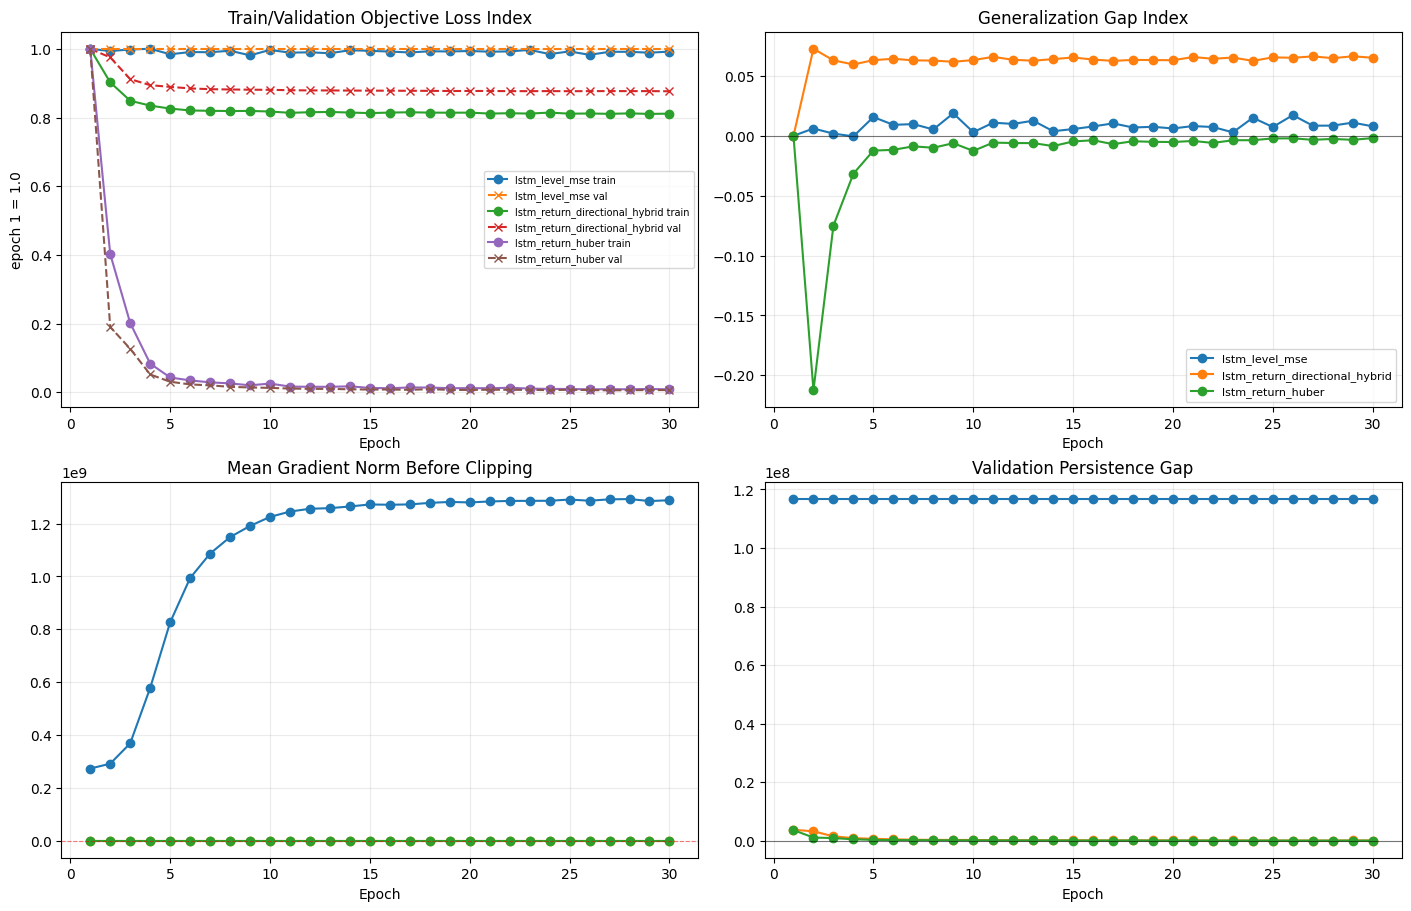

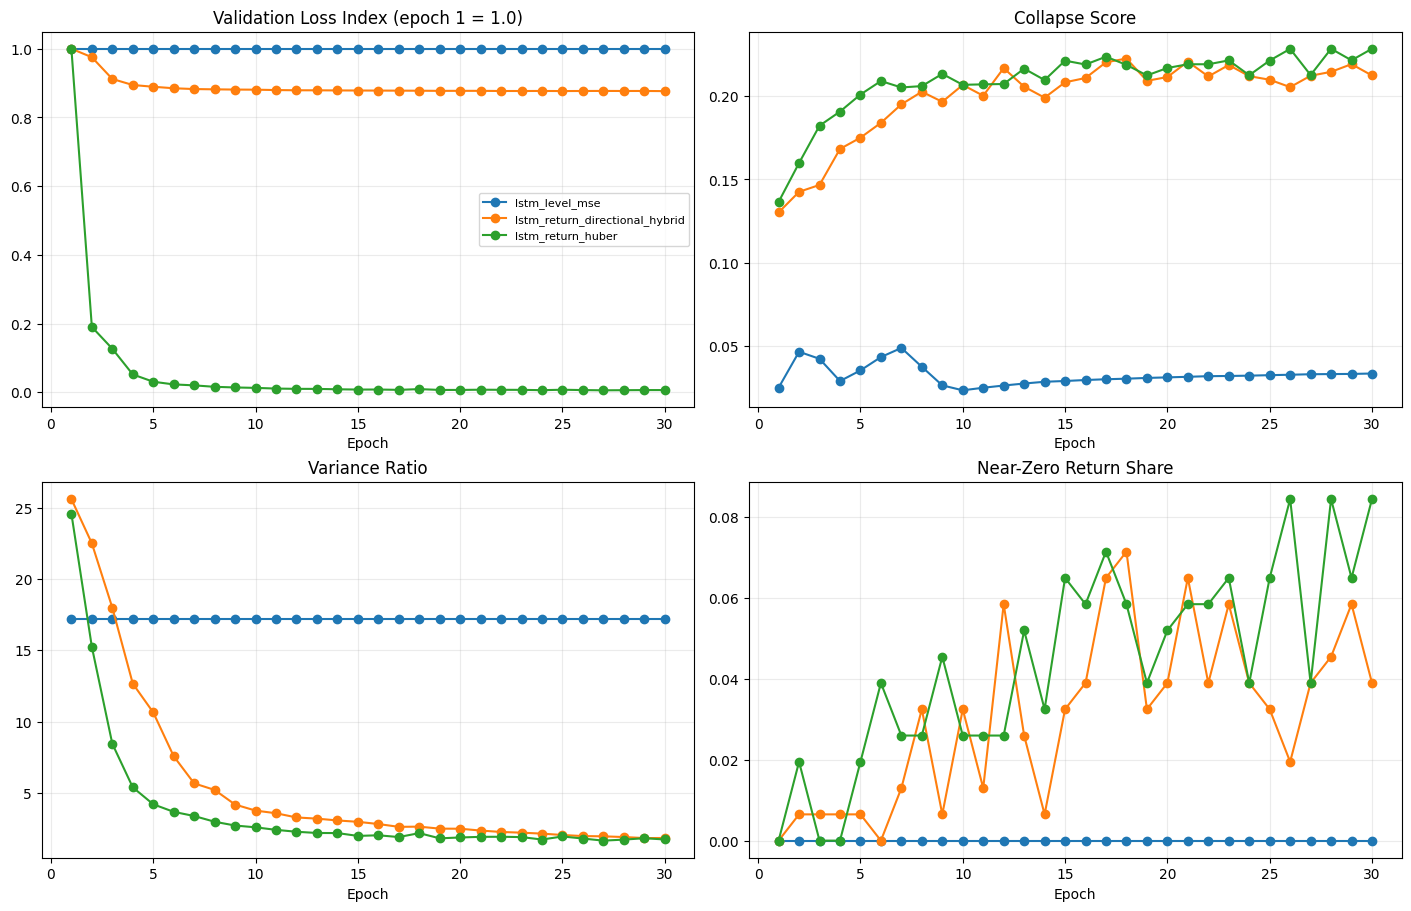

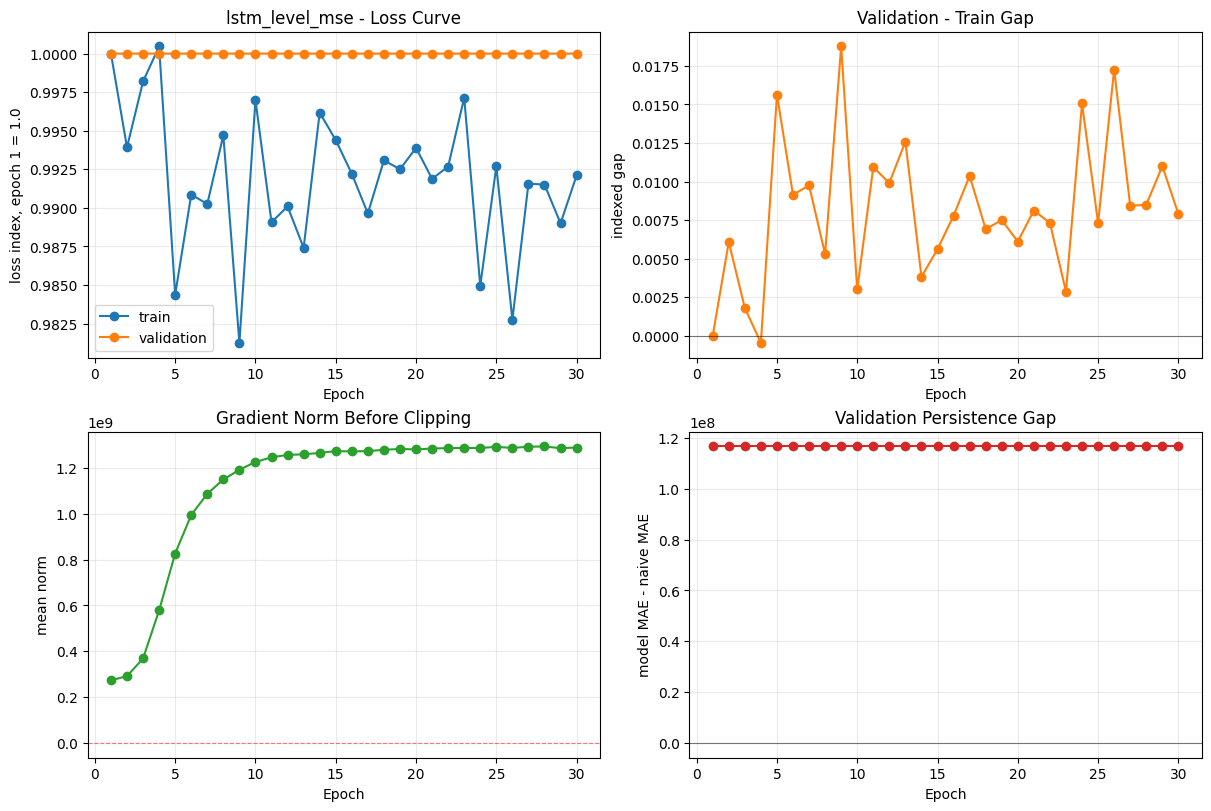

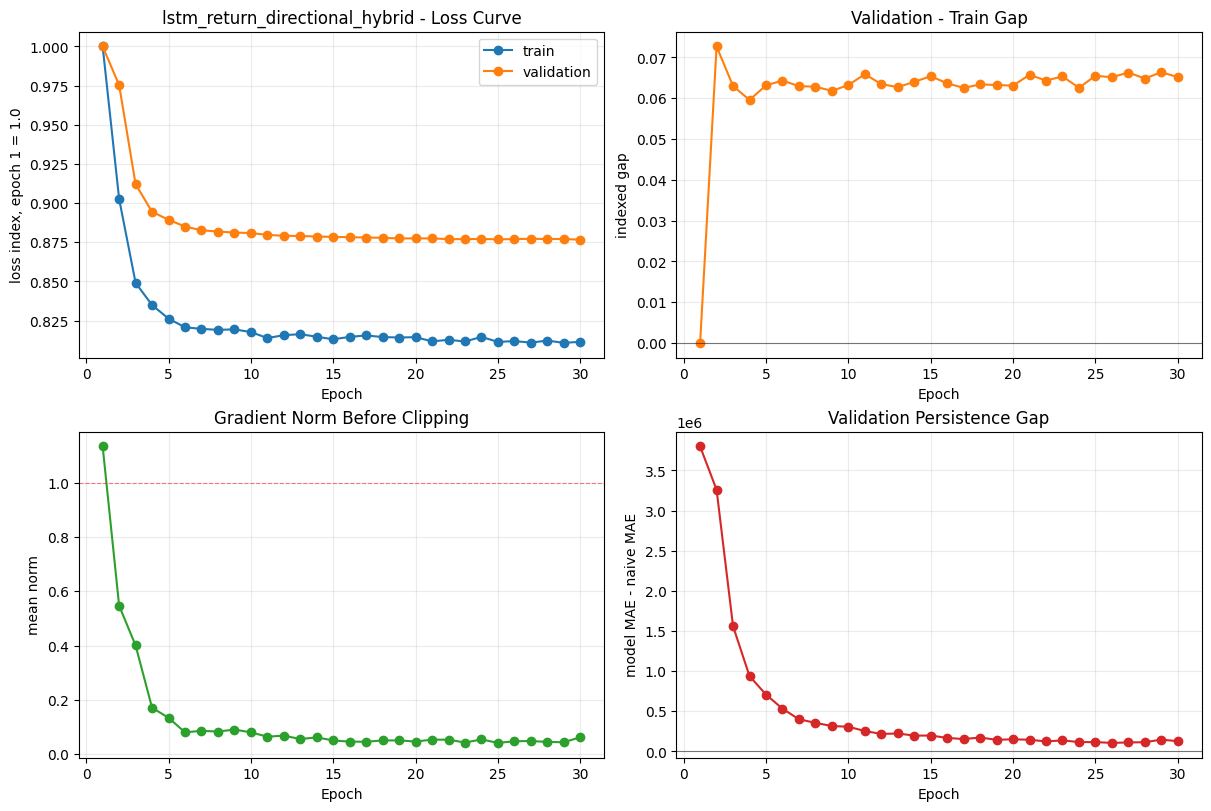

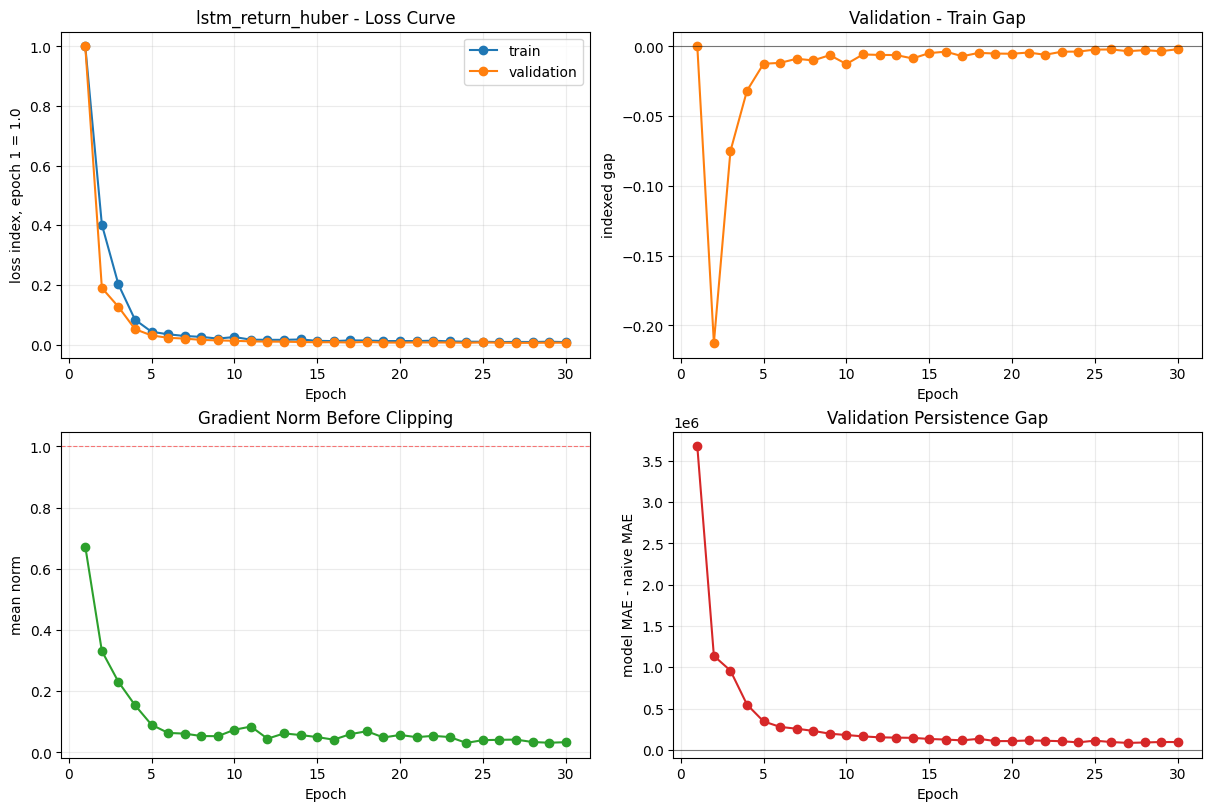

In [10]:
def display_latest_optimization_artifacts(artifacts: dict[str, object] | None = None) -> None:
    """Render the last generated report and figures in a notebook output cell."""
    artifacts = artifacts or globals().get("LAST_ARTIFACTS")
    if not artifacts:
        print("No optimization artifacts found yet. Run main() first.")
        return

    try:
        from IPython.display import Image, Markdown, display
    except ImportError:
        for name, value in artifacts.items():
            if isinstance(value, Path):
                print(f"{name}: {value}")
        return

    report_markdown = artifacts.get("report_markdown")
    if isinstance(report_markdown, str):
        display(Markdown(report_markdown))

    for key in ("training_figure", "collapse_figure"):
        fig = artifacts.get(key)
        if fig is not None:
            display(fig)

    case_figures = artifacts.get("case_figures", {})
    if isinstance(case_figures, dict):
        for _, fig in sorted(case_figures.items()):
            display(fig)

    report_path = artifacts.get("report_md")
    if isinstance(report_path, Path) and report_path.exists():
        display(Markdown(report_path.read_text(encoding="utf-8")))

    ordered_image_keys = [
        "training_figure_png",
        "collapse_figure_png",
        *sorted(key for key in artifacts if key.startswith("case_figure_")),
    ]
    for key in ordered_image_keys:
        image_path = artifacts.get(key)
        if isinstance(image_path, Path) and image_path.exists():
            display(Image(filename=str(image_path)))


if "ipykernel" in sys.modules:
    display_latest_optimization_artifacts()
